# Matrix Structure & Edge Cases: Colinear Track Study

**Purpose:** Investigate the Hamiltonian matrix behaviour when tracks share the same angular acceptance window, using simplified test events (3–4 layers, 2–4 colinear tracks). This notebook addresses two open questions from the supervisor meeting:

1. **What is the exact matrix structure when multiple tracks share the same search window?**  
   — Visualise the sparsity pattern, Gershgorin discs, eigenvalue spectrum, and condition number as track separation varies.

2. **Why do segment activations exceed 1.0 in the classical solver?**  
   — Derive the analytic solution for small chain systems and show that $x > 1$ is an expected mathematical consequence of the tridiagonal coupling, not a solver bug.

This extends the analysis in `recovery_separation_analysis.ipynb` with controlled, minimal-example experiments.

---

In [1]:
# ── 0. Setup ─────────────────────────────────────────────────────────────────
import sys, warnings
from pathlib import Path
from itertools import product as iterproduct

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.sparse.linalg import cg, spsolve
from scipy.linalg import eigvalsh, svdvals

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy.solvers import SimpleHamiltonianFast

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'legend.fontsize': 9,
    'axes.linewidth': 1.1, 'lines.linewidth': 1.8, 'lines.markersize': 5,
})

# ── Physics parameters (same as recovery_separation_analysis) ────────────────
SIGMA_SCATT = 1e-4
DZ_MM       = 33.0
SCALE       = 3.0
THETA_MIN   = 1.5e-5

EPSILON   = float(np.sqrt(2*(SCALE*SIGMA_SCATT)**2 + 2*THETA_MIN**2))
GAMMA     = 1.5
DELTA     = 1.0
BASELINE  = DELTA / (DELTA + GAMMA)
THRESHOLD = (1.0 + BASELINE) / 2.0

Z_PV = 50.0

print(f"ε = {EPSILON*1e3:.4f} mrad")
print(f"γ = {GAMMA},  δ = {DELTA},  baseline β = {BASELINE:.3f},  threshold τ = {THRESHOLD:.3f}")
print(f"Diagonal entry A_ii = δ+γ = {DELTA+GAMMA}")

ε = 0.4248 mrad
γ = 1.5,  δ = 1.0,  baseline β = 0.400,  threshold τ = 0.700
Diagonal entry A_ii = δ+γ = 2.5


In [2]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def make_geometry(n_mod, z_first=100.0, dz=DZ_MM, hx=50.0, hy=50.0):
    """Create a PlaneGeometry with n_mod modules."""
    return PlaneGeometry(
        module_id=list(range(n_mod)),
        lx=[hx]*n_mod, ly=[hy]*n_mod,
        z=[z_first + i*dz for i in range(n_mod)],
    )

def gen_colinear_event(n_tracks, n_modules, base_angle=0.01, separation_rad=0.0,
                       seed=42, z_pv=Z_PV, dz=DZ_MM, z_first=100.0):
    """
    Generate an event with n_tracks near-colinear tracks.
    
    Tracks are evenly spaced in tx around base_angle, with total spread
    = separation_rad.  ty = 0 for all tracks. No scattering, no measurement error.
    """
    geo = make_geometry(n_modules, z_first=z_first, dz=dz)
    
    # If separation is zero, all tracks get the same angle
    if n_tracks == 1 or separation_rad == 0.0:
        angles = [base_angle] * n_tracks
    else:
        angles = [base_angle + separation_rad * (i/(n_tracks-1) - 0.5)
                  for i in range(n_tracks)]
    
    # Override the random angle generation by manually setting particles
    gen = StateEventGenerator(
        detector_geometry=geo, events=1, n_particles=[n_tracks],
        phi_min=-0.3, phi_max=0.3, theta_min=-0.3, theta_max=0.3,
        measurement_error=0.0, collision_noise=0.0,  # no noise at all
    )
    gen.set_primary_vertices([(0.0, 0.0, z_pv)])
    gen.generate_particles([[{"type": "pion", "mass": 139.6, "q": 1}]*n_tracks])
    
    # Override the randomly-generated tx slopes with our controlled values
    np.random.seed(seed)
    for i, ang in enumerate(angles):
        gen.particles[0][i]['tx'] = np.tan(ang)
        gen.particles[0][i]['ty'] = 0.0
    
    event = gen.generate_complete_events()
    return event, geo, angles

def build_ham(event, epsilon=EPSILON, gamma=GAMMA, delta=DELTA):
    ham = SimpleHamiltonianFast(epsilon=epsilon, gamma=gamma, delta=delta)
    ham.construct_hamiltonian(event)
    return ham

def label_segments(ham, event):
    true_set = set()
    for trk in event.tracks:
        h = trk.hit_ids
        for k in range(len(h)-1):
            true_set.add((h[k], h[k+1]))
    return np.array([ham._segment_to_hit_ids[i] in true_set
                     for i in range(ham.n_segments)])

def get_matrix_dense(ham):
    return ham.A.toarray()

def spectral_analysis(A_dense):
    """Return eigenvalues, singular values, condition number, definiteness."""
    eigs = eigvalsh(A_dense)
    svs  = svdvals(A_dense)
    kappa = svs[0] / svs[-1] if svs[-1] > 1e-15 else np.inf
    is_pd = bool(np.all(eigs > 0))
    return eigs, svs, kappa, is_pd

def gershgorin_discs(A_dense):
    """Return centres, radii, and ratios for each row."""
    n = A_dense.shape[0]
    centres = np.diag(A_dense).copy()
    radii = np.array([np.sum(np.abs(A_dense[i])) - np.abs(A_dense[i,i]) for i in range(n)])
    ratios = radii / np.abs(centres)
    return centres, radii, ratios

print("Helpers defined.")

Helpers defined.


---
## 1 — Event Display: Visualising Colinear Tracks

First, we create minimal test events and visualise the geometry to confirm the tracks and hits are sensible.

In [3]:
# ── 1a. Create test events with 3 modules and 2, 3, 4 tracks ────────────────
N_MOD = 3

# Well separated (10 mrad apart — far above ε ≈ 0.42 mrad)
ev_sep, geo_sep, ang_sep = gen_colinear_event(2, N_MOD, base_angle=0.01, separation_rad=0.01)
# Nearly coincident (0.05 mrad apart — well below ε/f_amp ≈ 0.12 mrad)
ev_coin, geo_coin, ang_coin = gen_colinear_event(2, N_MOD, base_angle=0.01, separation_rad=5e-5)
# Exactly colinear (separation = 0)
ev_exact, geo_exact, ang_exact = gen_colinear_event(2, N_MOD, base_angle=0.01, separation_rad=0.0)

print("Track angles (mrad):")
print(f"  Well-separated:    {[a*1e3 for a in ang_sep]}")
print(f"  Near-coincident:   {[a*1e3 for a in ang_coin]}")
print(f"  Exactly colinear:  {[a*1e3 for a in ang_exact]}")
print()
for label, ev in [("Separated", ev_sep), ("Coincident", ev_coin), ("Exact", ev_exact)]:
    print(f"{label}: {len(ev.tracks)} tracks, {len(ev.hits)} hits, "
          f"hits-per-track = {[len(t.hit_ids) for t in ev.tracks]}")

Track angles (mrad):
  Well-separated:    [5.0, 15.0]
  Near-coincident:   [9.975, 10.025]
  Exactly colinear:  [10.0, 10.0]

Separated: 2 tracks, 6 hits, hits-per-track = [3, 3]
Coincident: 2 tracks, 6 hits, hits-per-track = [3, 3]
Exact: 2 tracks, 6 hits, hits-per-track = [3, 3]


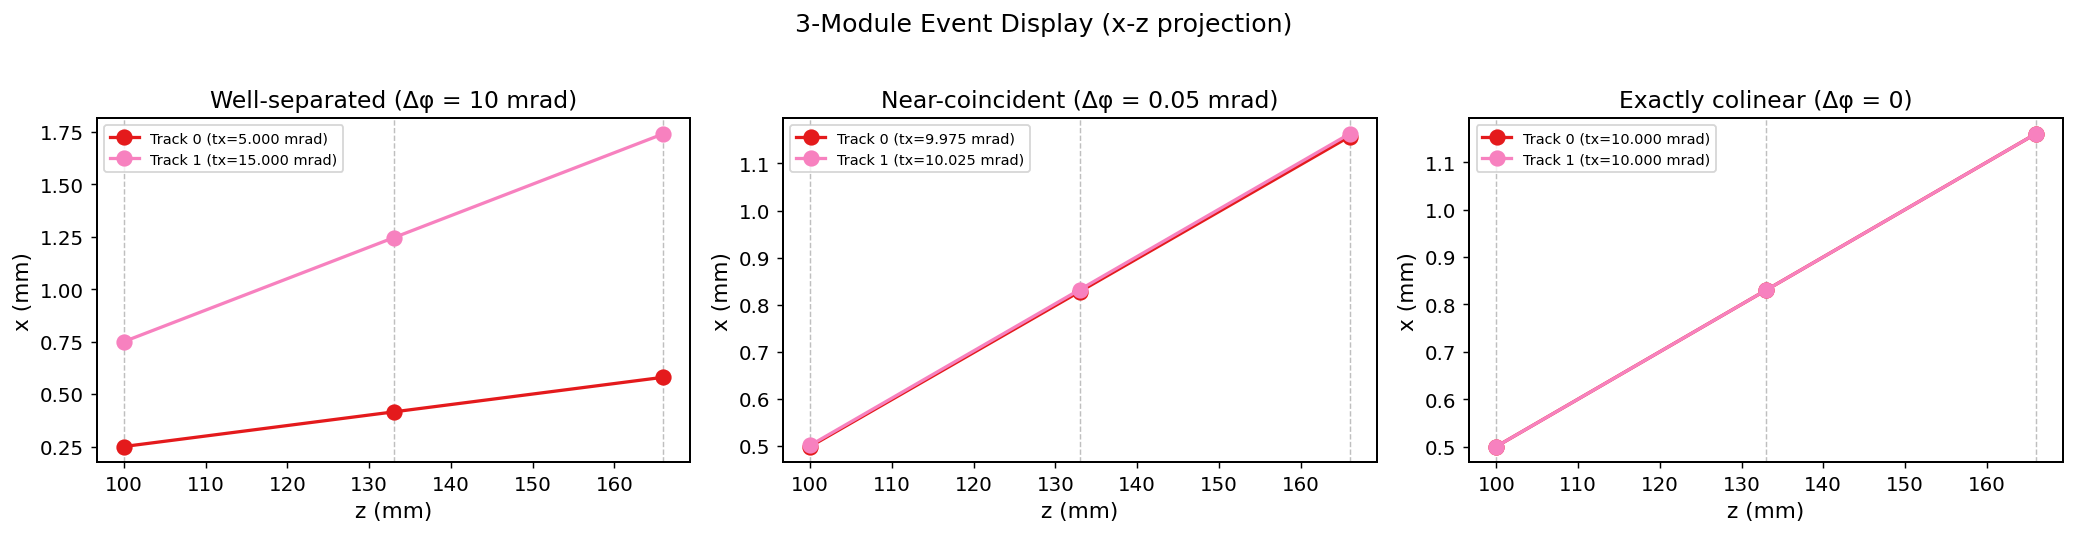

In [4]:
# ── 1b. Event display: x-z view ────────────────────────────────────────────
def plot_event_xz(event, geo, angles, ax, title=""):
    """Draw tracks and hits in the x-z plane."""
    z_positions = [z for _, _, _, z in geo]
    
    # Draw module planes
    for z in z_positions:
        ax.axvline(z, color='grey', ls='--', lw=0.8, alpha=0.5)
    
    colors = plt.cm.Set1(np.linspace(0, 0.8, len(event.tracks)))
    for i, trk in enumerate(event.tracks):
        hits = event.get_hits_by_ids(trk.hit_ids)
        zs = [h.z for h in hits]
        xs = [h.x for h in hits]
        ax.plot(zs, xs, 'o-', color=colors[i], label=f'Track {i} (tx={angles[i]*1e3:.3f} mrad)',
                markersize=8, zorder=3)
    ax.set_xlabel('z (mm)')
    ax.set_ylabel('x (mm)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_event_xz(ev_sep, geo_sep, ang_sep, axes[0], "Well-separated (Δφ = 10 mrad)")
plot_event_xz(ev_coin, geo_coin, ang_coin, axes[1], "Near-coincident (Δφ = 0.05 mrad)")
plot_event_xz(ev_exact, geo_exact, ang_exact, axes[2], "Exactly colinear (Δφ = 0)")
fig.suptitle(f'{N_MOD}-Module Event Display (x-z projection)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_event_display_xz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2 — Segment Enumeration & Coupling Map

For a 3-module detector with $n$ tracks, there are $(M-1) n^2 = 2n^2$ candidate segments. We enumerate all segments, label them true/false/cross, and show which pairs are coupled in the Hamiltonian matrix.

In [5]:
# ── 2a. Segment enumeration for the three 2-track cases ─────────────────────
def segment_report(event, label):
    ham = build_ham(event)
    A = get_matrix_dense(ham)
    is_true = label_segments(ham, event)
    n_seg = ham.n_segments
    
    # Count off-diagonal non-zeros (symmetric, so count pairs)
    n_offdiag = (np.count_nonzero(A) - n_seg)  # total nonzeros minus diagonal
    
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Segments: {n_seg} total, {np.sum(is_true)} true, {np.sum(~is_true)} false")
    print(f"  Off-diagonal entries: {n_offdiag} (i.e. {n_offdiag//2} coupling pairs)")
    print()
    
    # Print each segment
    print(f"  {'Seg':>4}  {'From→To':>12}  {'True?':>5}  {'Row sum R_i':>11}  {'ρ_i':>6}")
    print(f"  {'-'*45}")
    for i in range(n_seg):
        fid, tid = ham._segment_to_hit_ids[i]
        R_i = np.sum(np.abs(A[i])) - np.abs(A[i,i])
        rho = R_i / np.abs(A[i,i])
        flag = '✓' if is_true[i] else '✗'
        warn = ' ← ρ > 1 !' if rho > 1 else ''
        print(f"  {i:>4}  hit {fid:>2} → {tid:<2}     {flag:>5}  {R_i:>11.1f}  {rho:>6.2f}{warn}")
    
    return ham, A, is_true

ham_sep, A_sep, mask_sep = segment_report(ev_sep, "Well-separated (Δφ = 10 mrad)")
ham_coin, A_coin, mask_coin = segment_report(ev_coin, "Near-coincident (Δφ = 0.05 mrad)")
ham_exact, A_exact, mask_exact = segment_report(ev_exact, "Exactly colinear (Δφ = 0)")


  Well-separated (Δφ = 10 mrad)
  Segments: 8 total, 4 true, 4 false
  Off-diagonal entries: 4 (i.e. 2 coupling pairs)

   Seg       From→To  True?  Row sum R_i     ρ_i
  ---------------------------------------------
     0  hit  0 → 1          ✓          1.0    0.40
     1  hit  0 → 4          ✗          0.0    0.00
     2  hit  3 → 1          ✗          0.0    0.00
     3  hit  3 → 4          ✓          1.0    0.40
     4  hit  1 → 2          ✓          1.0    0.40
     5  hit  1 → 5          ✗          0.0    0.00
     6  hit  4 → 2          ✗          0.0    0.00
     7  hit  4 → 5          ✓          1.0    0.40

  Near-coincident (Δφ = 0.05 mrad)
  Segments: 8 total, 4 true, 4 false
  Off-diagonal entries: 16 (i.e. 8 coupling pairs)

   Seg       From→To  True?  Row sum R_i     ρ_i
  ---------------------------------------------
     0  hit  0 → 1          ✓          2.0    0.80
     1  hit  0 → 4          ✗          2.0    0.80
     2  hit  3 → 1          ✗          2.0    0.80

/tmp/ipykernel_3304455/2298725090.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


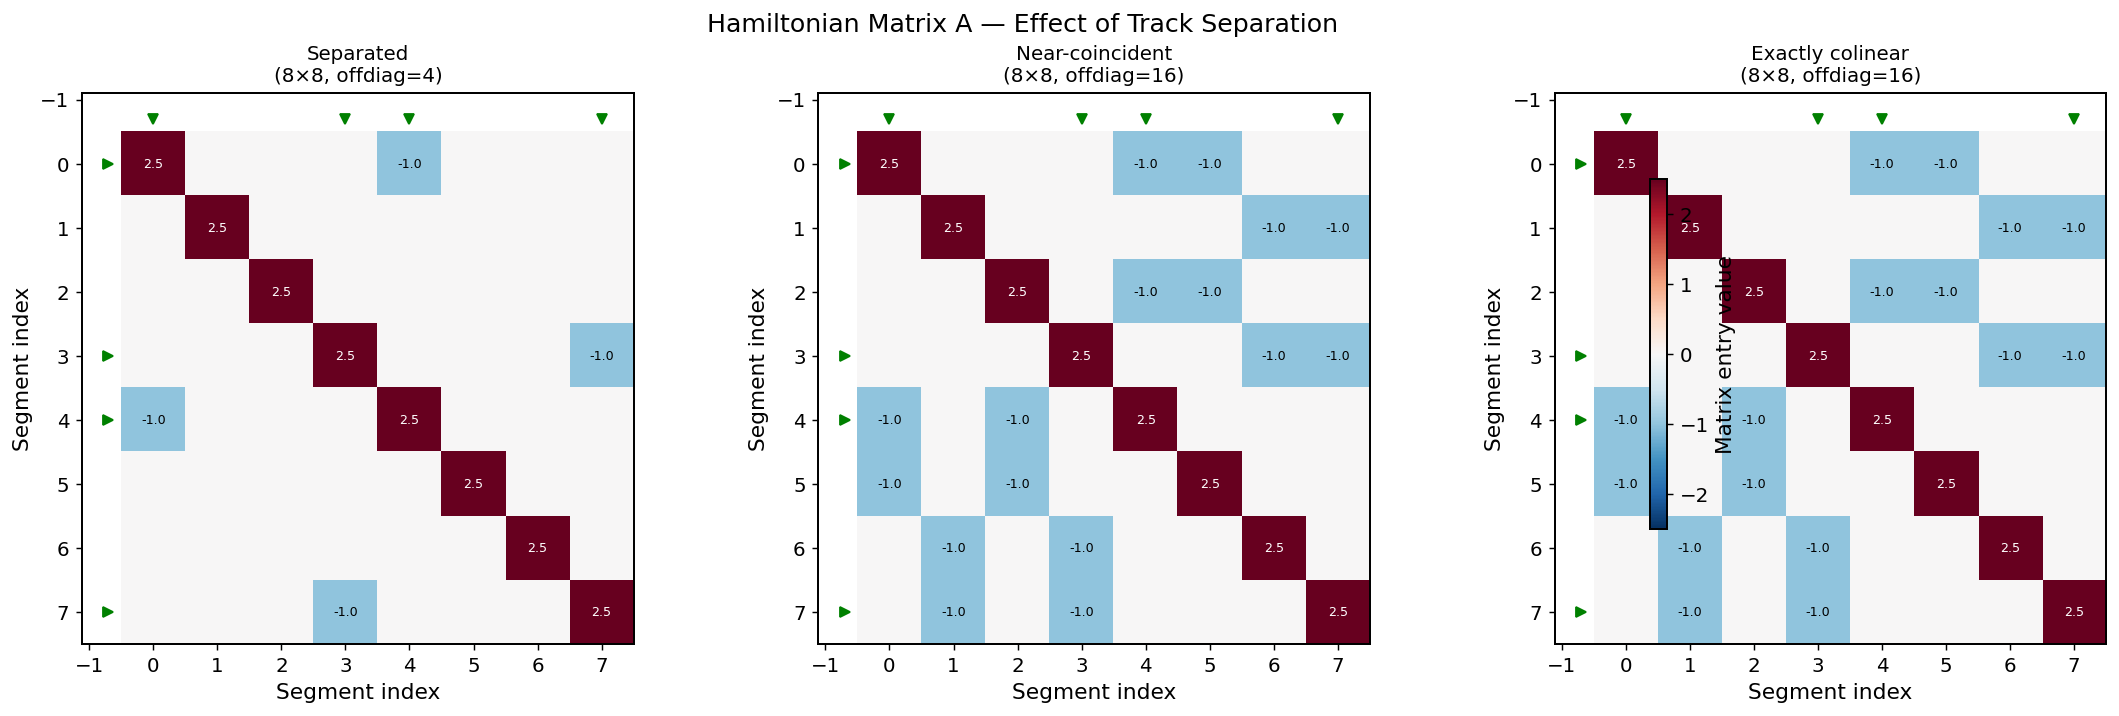

In [6]:
# ── 2b. Matrix heat-maps side by side ───────────────────────────────────────
def plot_matrix(A, is_true, ax, title):
    n = A.shape[0]
    vmax = max(abs(A.min()), abs(A.max()))
    im = ax.imshow(A, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Segment index')
    ax.set_ylabel('Segment index')
    
    # Mark true segments on axes
    for i in range(n):
        if is_true[i]:
            ax.plot(i, -0.7, 'v', color='green', markersize=5, clip_on=False)
            ax.plot(-0.7, i, '>', color='green', markersize=5, clip_on=False)
    
    # Annotate matrix values for small matrices
    if n <= 12:
        for i in range(n):
            for j in range(n):
                if A[i,j] != 0:
                    ax.text(j, i, f'{A[i,j]:.1f}', ha='center', va='center',
                            fontsize=7, color='black' if abs(A[i,j]) < vmax*0.5 else 'white')
    return im

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (A, mask, title) in zip(axes, [
    (A_sep, mask_sep, f"Separated\n({A_sep.shape[0]}×{A_sep.shape[0]}, offdiag={(np.count_nonzero(A_sep)-A_sep.shape[0])})"),
    (A_coin, mask_coin, f"Near-coincident\n({A_coin.shape[0]}×{A_coin.shape[0]}, offdiag={(np.count_nonzero(A_coin)-A_coin.shape[0])})"),
    (A_exact, mask_exact, f"Exactly colinear\n({A_exact.shape[0]}×{A_exact.shape[0]}, offdiag={(np.count_nonzero(A_exact)-A_exact.shape[0])})")
]):
    im = plot_matrix(A, mask, ax, title)

fig.colorbar(im, ax=axes, shrink=0.7, label='Matrix entry value')
fig.suptitle('Hamiltonian Matrix A — Effect of Track Separation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_matrix_heatmaps_3mod.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 — Gershgorin Disc Visualisation

The Gershgorin disc $D_i = \{z : |z - A_{ii}| \leq R_i\}$ bounds eigenvalue locations. When $R_i > |A_{ii}|$ the disc crosses zero, and the matrix may become indefinite.

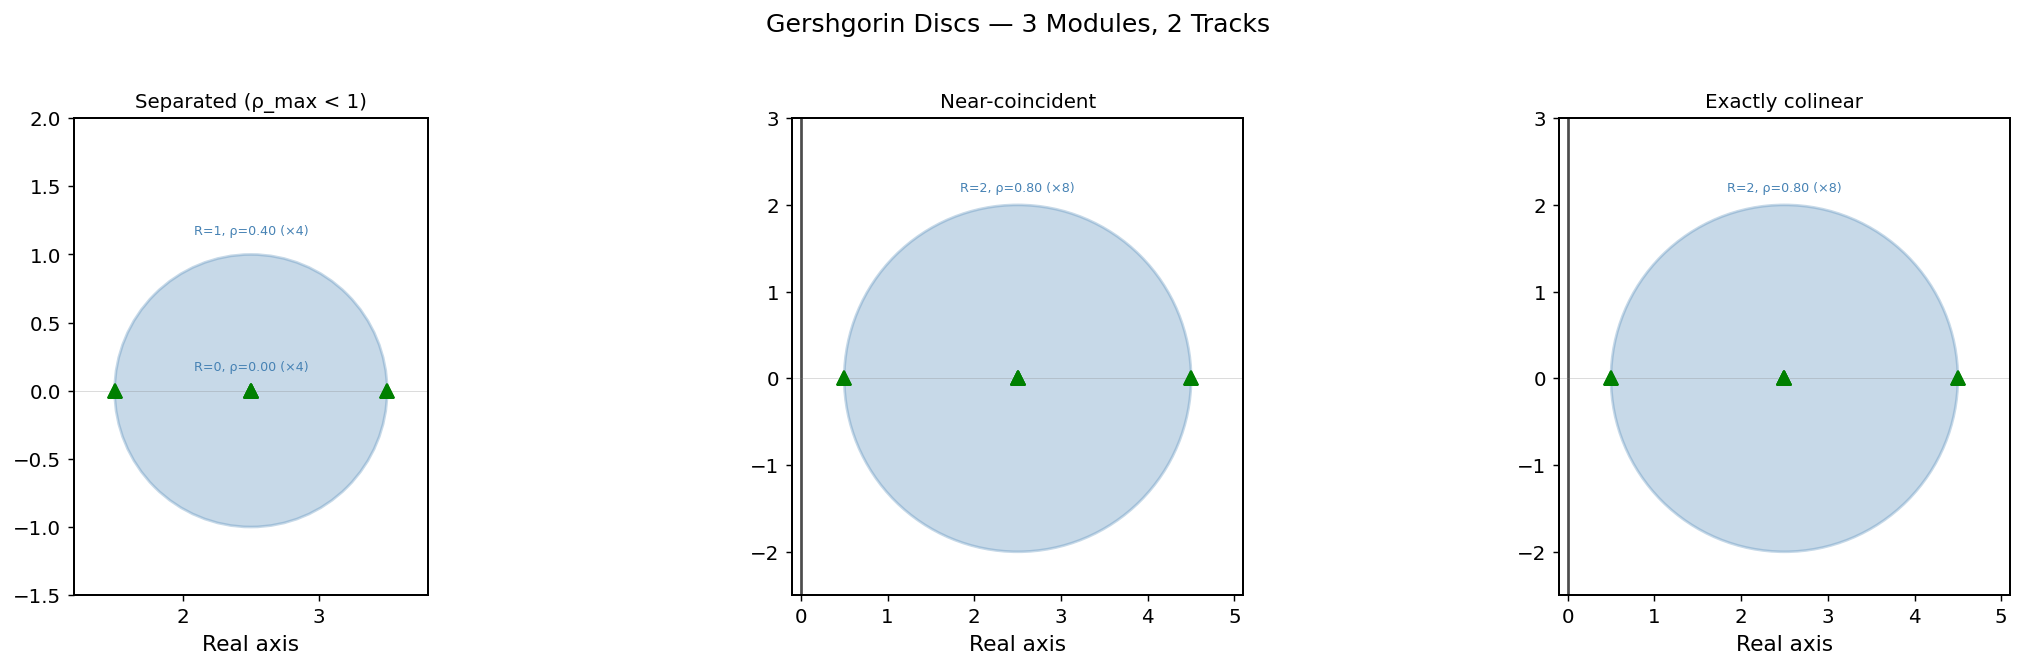

Case                     ρ_max     λ_min     λ_max    κ(SVD)   PD?
--------------------------------------------------------------
Separated                 0.40     1.500     3.500       2.3   Yes
Near-coincident           0.80     0.500     4.500       9.0   Yes
Exactly colinear          0.80     0.500     4.500       9.0   Yes


In [7]:
# ── 3. Gershgorin disc plots ────────────────────────────────────────────────
def plot_gershgorin(A, ax, title, show_eigs=True):
    centres, radii, ratios = gershgorin_discs(A)
    eigs = eigvalsh(A)
    n = len(centres)
    
    # Group identical discs
    seen = {}
    for i in range(n):
        key = (round(centres[i], 6), round(radii[i], 6))
        if key not in seen:
            seen[key] = 0
        seen[key] += 1
    
    # Plot discs
    y_offset = 0
    for (c, r), count in seen.items():
        rho = r / abs(c) if abs(c) > 1e-12 else np.inf 
        color = 'red' if rho > 1 else ('orange' if rho > 0.8 else 'steelblue')
        alpha = 0.3
        disc = Circle((c, y_offset), r, fill=True, facecolor=color, edgecolor=color,
                      alpha=alpha, linewidth=1.5)
        ax.add_patch(disc)
        label = f"R={r:.0f}, ρ={rho:.2f}" + (f" (×{count})" if count > 1 else "")
        ax.text(c, y_offset + r + 0.15, label, ha='center', fontsize=7, color=color)
        y_offset += 0.0  # stack at same y for simplicity
    
    # Eigenvalues
    if show_eigs:
        for ev in eigs:
            marker = 'v' if ev < 0 else '^'
            color = 'red' if ev < 0 else 'green'
            ax.plot(ev, 0, marker, color=color, markersize=8, zorder=5)
    
    # Zero line
    ax.axvline(0, color='black', ls='-', lw=1.5, alpha=0.7)
    ax.axhline(0, color='grey', ls='-', lw=0.5, alpha=0.3)
    
    # Formatting
    all_left  = min(c - r for c, r in seen.keys())
    all_right = max(c + r for c, r in seen.keys())
    margin = (all_right - all_left) * 0.15
    ax.set_xlim(all_left - margin, all_right + margin)
    rmax = max(r for _, r in seen.keys())
    ax.set_ylim(-rmax - 0.5, rmax + 1.0)
    ax.set_xlabel('Real axis')
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_gershgorin(A_sep, axes[0], "Separated (ρ_max < 1)")
plot_gershgorin(A_coin, axes[1], "Near-coincident")
plot_gershgorin(A_exact, axes[2], "Exactly colinear")
fig.suptitle('Gershgorin Discs — 3 Modules, 2 Tracks', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_gershgorin_3mod.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'Case':<22}  {'ρ_max':>6}  {'λ_min':>8}  {'λ_max':>8}  {'κ(SVD)':>8}  {'PD?':>4}")
print('-'*62)
for label, A in [("Separated", A_sep), ("Near-coincident", A_coin), ("Exactly colinear", A_exact)]:
    eigs, svs, kappa, is_pd = spectral_analysis(A)
    _, _, ratios = gershgorin_discs(A)
    print(f"{label:<22}  {ratios.max():>6.2f}  {eigs.min():>8.3f}  {eigs.max():>8.3f}  {kappa:>8.1f}  {'Yes' if is_pd else 'NO':>4}")

---
## 4 — Scaling Up: 3 and 4 Colinear Tracks

Now we examine what happens with more tracks sharing the acceptance window. Each additional track adds more cross-segments and further inflates the Gershgorin radii.

In [8]:
# ── 4a. Build events with 2, 3, 4 colinear tracks on 3 and 4 modules ──────
configs = []
for n_mod in [3, 4]:
    for n_trk in [2, 3, 4]:
        ev, geo, angles = gen_colinear_event(n_trk, n_mod, base_angle=0.01, 
                                             separation_rad=0.0)
        ham = build_ham(ev)
        A = get_matrix_dense(ham)
        is_true = label_segments(ham, ev)
        eigs, svs, kappa, is_pd = spectral_analysis(A)
        centres, radii, ratios = gershgorin_discs(A)
        
        configs.append({
            'n_mod': n_mod, 'n_trk': n_trk,
            'n_seg': ham.n_segments, 'n_true': int(np.sum(is_true)),
            'n_offdiag': np.count_nonzero(A) - ham.n_segments,
            'rho_max': ratios.max(), 'R_max': radii.max(),
            'lam_min': eigs.min(), 'lam_max': eigs.max(),
            'kappa': kappa, 'is_pd': is_pd,
            'A': A, 'is_true': is_true, 'eigs': eigs,
        })

# Summary table
print(f"{'Modules':>7} {'Tracks':>6} {'N_seg':>6} {'True':>5} {'Offdiag':>8} "
      f"{'R_max':>6} {'ρ_max':>6} {'λ_min':>8} {'κ(SVD)':>8} {'PD?':>4}")
print('-'*78)
for c in configs:
    print(f"{c['n_mod']:>7} {c['n_trk']:>6} {c['n_seg']:>6} {c['n_true']:>5} {c['n_offdiag']:>8} "
          f"{c['R_max']:>6.1f} {c['rho_max']:>6.2f} {c['lam_min']:>8.3f} {c['kappa']:>8.1f} "
          f"{'Yes' if c['is_pd'] else 'NO':>4}")

Modules Tracks  N_seg  True  Offdiag  R_max  ρ_max    λ_min   κ(SVD)  PD?
------------------------------------------------------------------------------
      3      2      8     4       16    2.0   0.80    0.500      9.0  Yes
      3      3     18     6       54    3.0   1.20   -0.500     11.0   NO
      3      4     32     8      128    4.0   1.60   -1.500      4.3   NO
      4      2     12     6       32    4.0   1.60   -0.328     16.2   NO
      4      3     27     9      108    6.0   2.40   -1.743     13.5   NO
      4      4     48    12      256    8.0   3.20   -3.157      5.4   NO


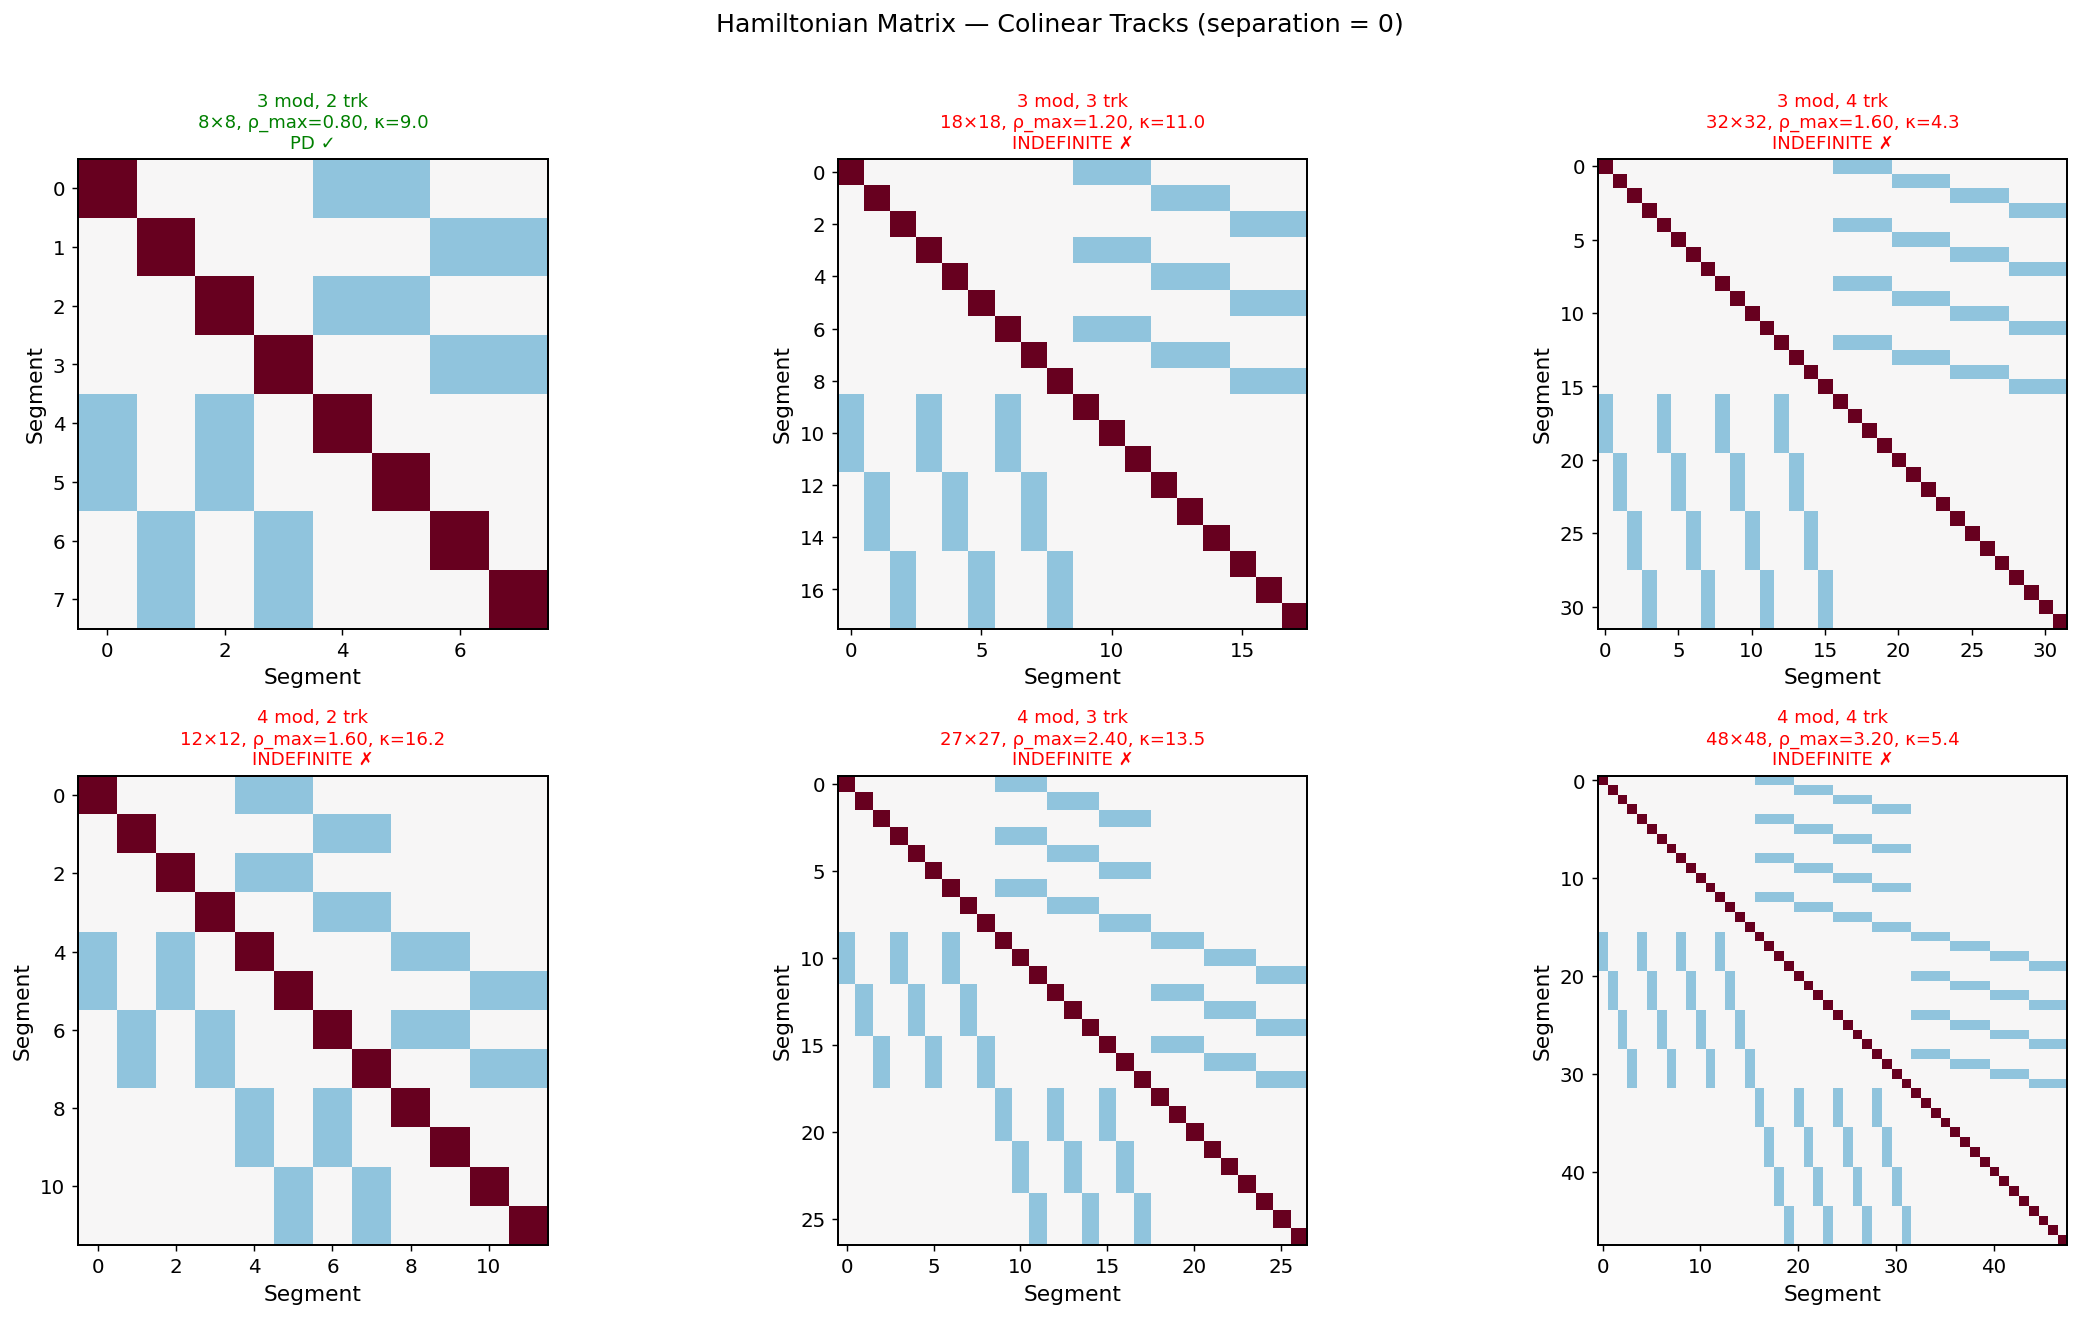

In [9]:
# ── 4b. Matrix heatmaps for all configurations ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, c in enumerate(configs):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    A = c['A']
    n = A.shape[0]
    vmax = max(abs(A.min()), abs(A.max()))
    ax.imshow(A, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_title(f"{c['n_mod']} mod, {c['n_trk']} trk\n"
                 f"{n}×{n}, ρ_max={c['rho_max']:.2f}, κ={c['kappa']:.1f}\n"
                 f"{'PD ✓' if c['is_pd'] else 'INDEFINITE ✗'}",
                 fontsize=10, color='green' if c['is_pd'] else 'red')
    ax.set_xlabel('Segment')
    ax.set_ylabel('Segment')

fig.suptitle('Hamiltonian Matrix — Colinear Tracks (separation = 0)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_matrix_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

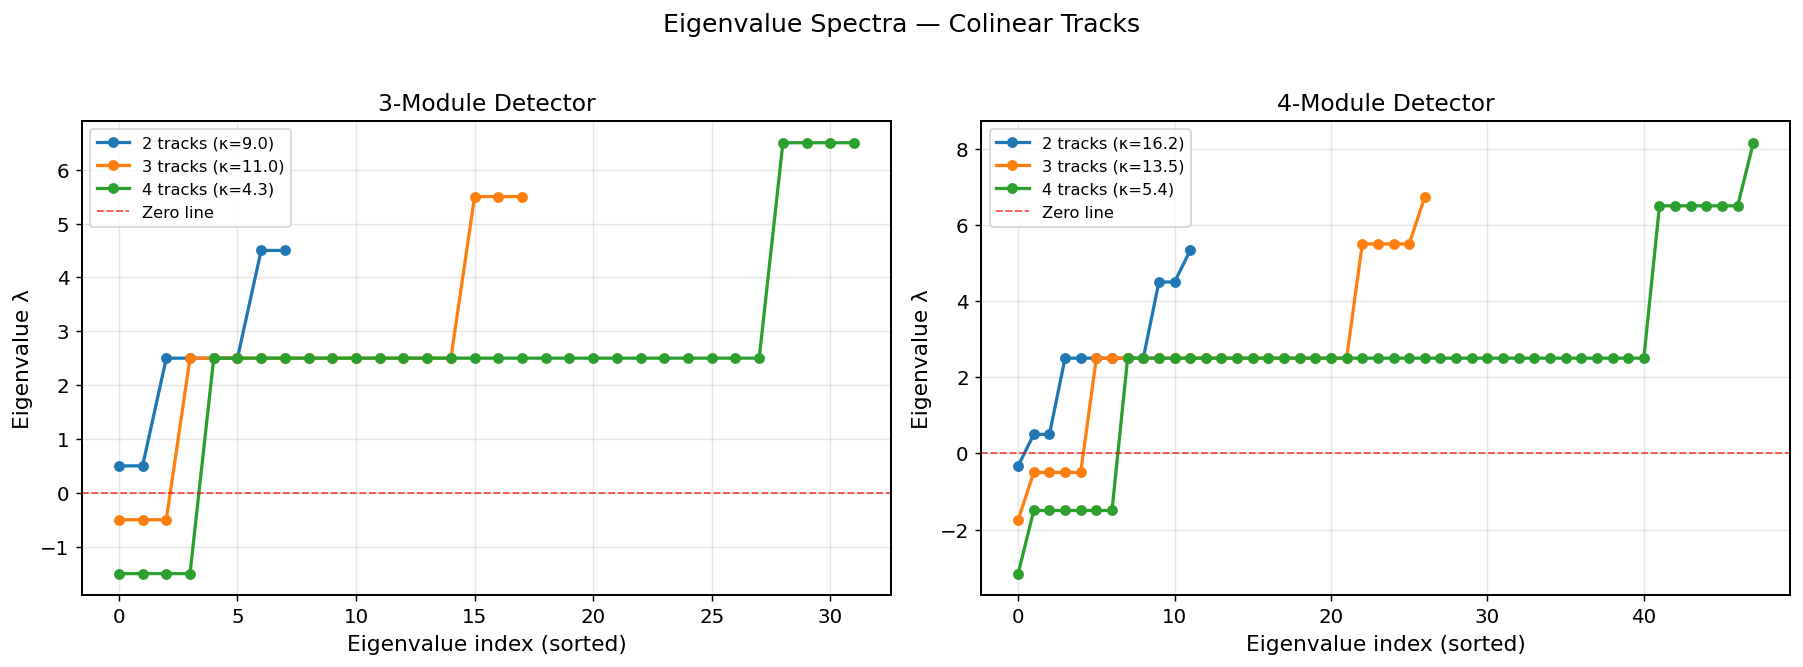

In [10]:
# ── 4c. Eigenvalue spectrum comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_mod_plot, ax in zip([3, 4], axes):
    for c in configs:
        if c['n_mod'] != n_mod_plot:
            continue
        eigs = c['eigs']
        ax.plot(range(len(eigs)), np.sort(eigs), 'o-', 
                label=f"{c['n_trk']} tracks (κ={c['kappa']:.1f})")
    ax.axhline(0, color='red', ls='--', lw=1, alpha=0.7, label='Zero line')
    ax.set_xlabel('Eigenvalue index (sorted)')
    ax.set_ylabel('Eigenvalue λ')
    ax.set_title(f'{n_mod_plot}-Module Detector')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Eigenvalue Spectra — Colinear Tracks', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_eigenvalue_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 — Separation Sweep: Transition from Block-Diagonal to Cross-Coupled

We sweep the angular separation between two tracks from 0 to 10 mrad and track how the matrix properties evolve. The critical transition occurs at $\Delta\phi_\text{eff} \approx \varepsilon / f_\text{amp}$.

In [11]:
# ── 5. Separation sweep ─────────────────────────────────────────────────────
separations = np.concatenate([
    np.linspace(0, 0.0003, 30),    # fine sampling around the critical region
    np.linspace(0.0004, 0.002, 20),
    np.linspace(0.003, 0.01, 10),
])

sweep_results = []
for sep in separations:
    for n_mod in [3, 4, 5]:
        ev, geo, angs = gen_colinear_event(2, n_mod, base_angle=0.01, separation_rad=sep)
        ham = build_ham(ev)
        A = get_matrix_dense(ham)
        eigs, svs, kappa, is_pd = spectral_analysis(A)
        _, radii, ratios = gershgorin_discs(A)
        n_offdiag = np.count_nonzero(A) - ham.n_segments
        
        # Solve and get activations
        sol = spsolve(ham.A, ham.b)
        is_true = label_segments(ham, ev)
        
        sweep_results.append({
            'sep': sep, 'n_mod': n_mod,
            'n_offdiag': n_offdiag,
            'rho_max': ratios.max(), 'R_max': radii.max(),
            'lam_min': eigs.min(), 'kappa': kappa, 'is_pd': is_pd,
            'x_true_max': sol[is_true].max() if np.any(is_true) else np.nan,
            'x_true_min': sol[is_true].min() if np.any(is_true) else np.nan,
            'x_false_mean': sol[~is_true].mean() if np.any(~is_true) else np.nan,
        })

print(f"Sweep complete: {len(sweep_results)} configurations tested.")

Sweep complete: 180 configurations tested.


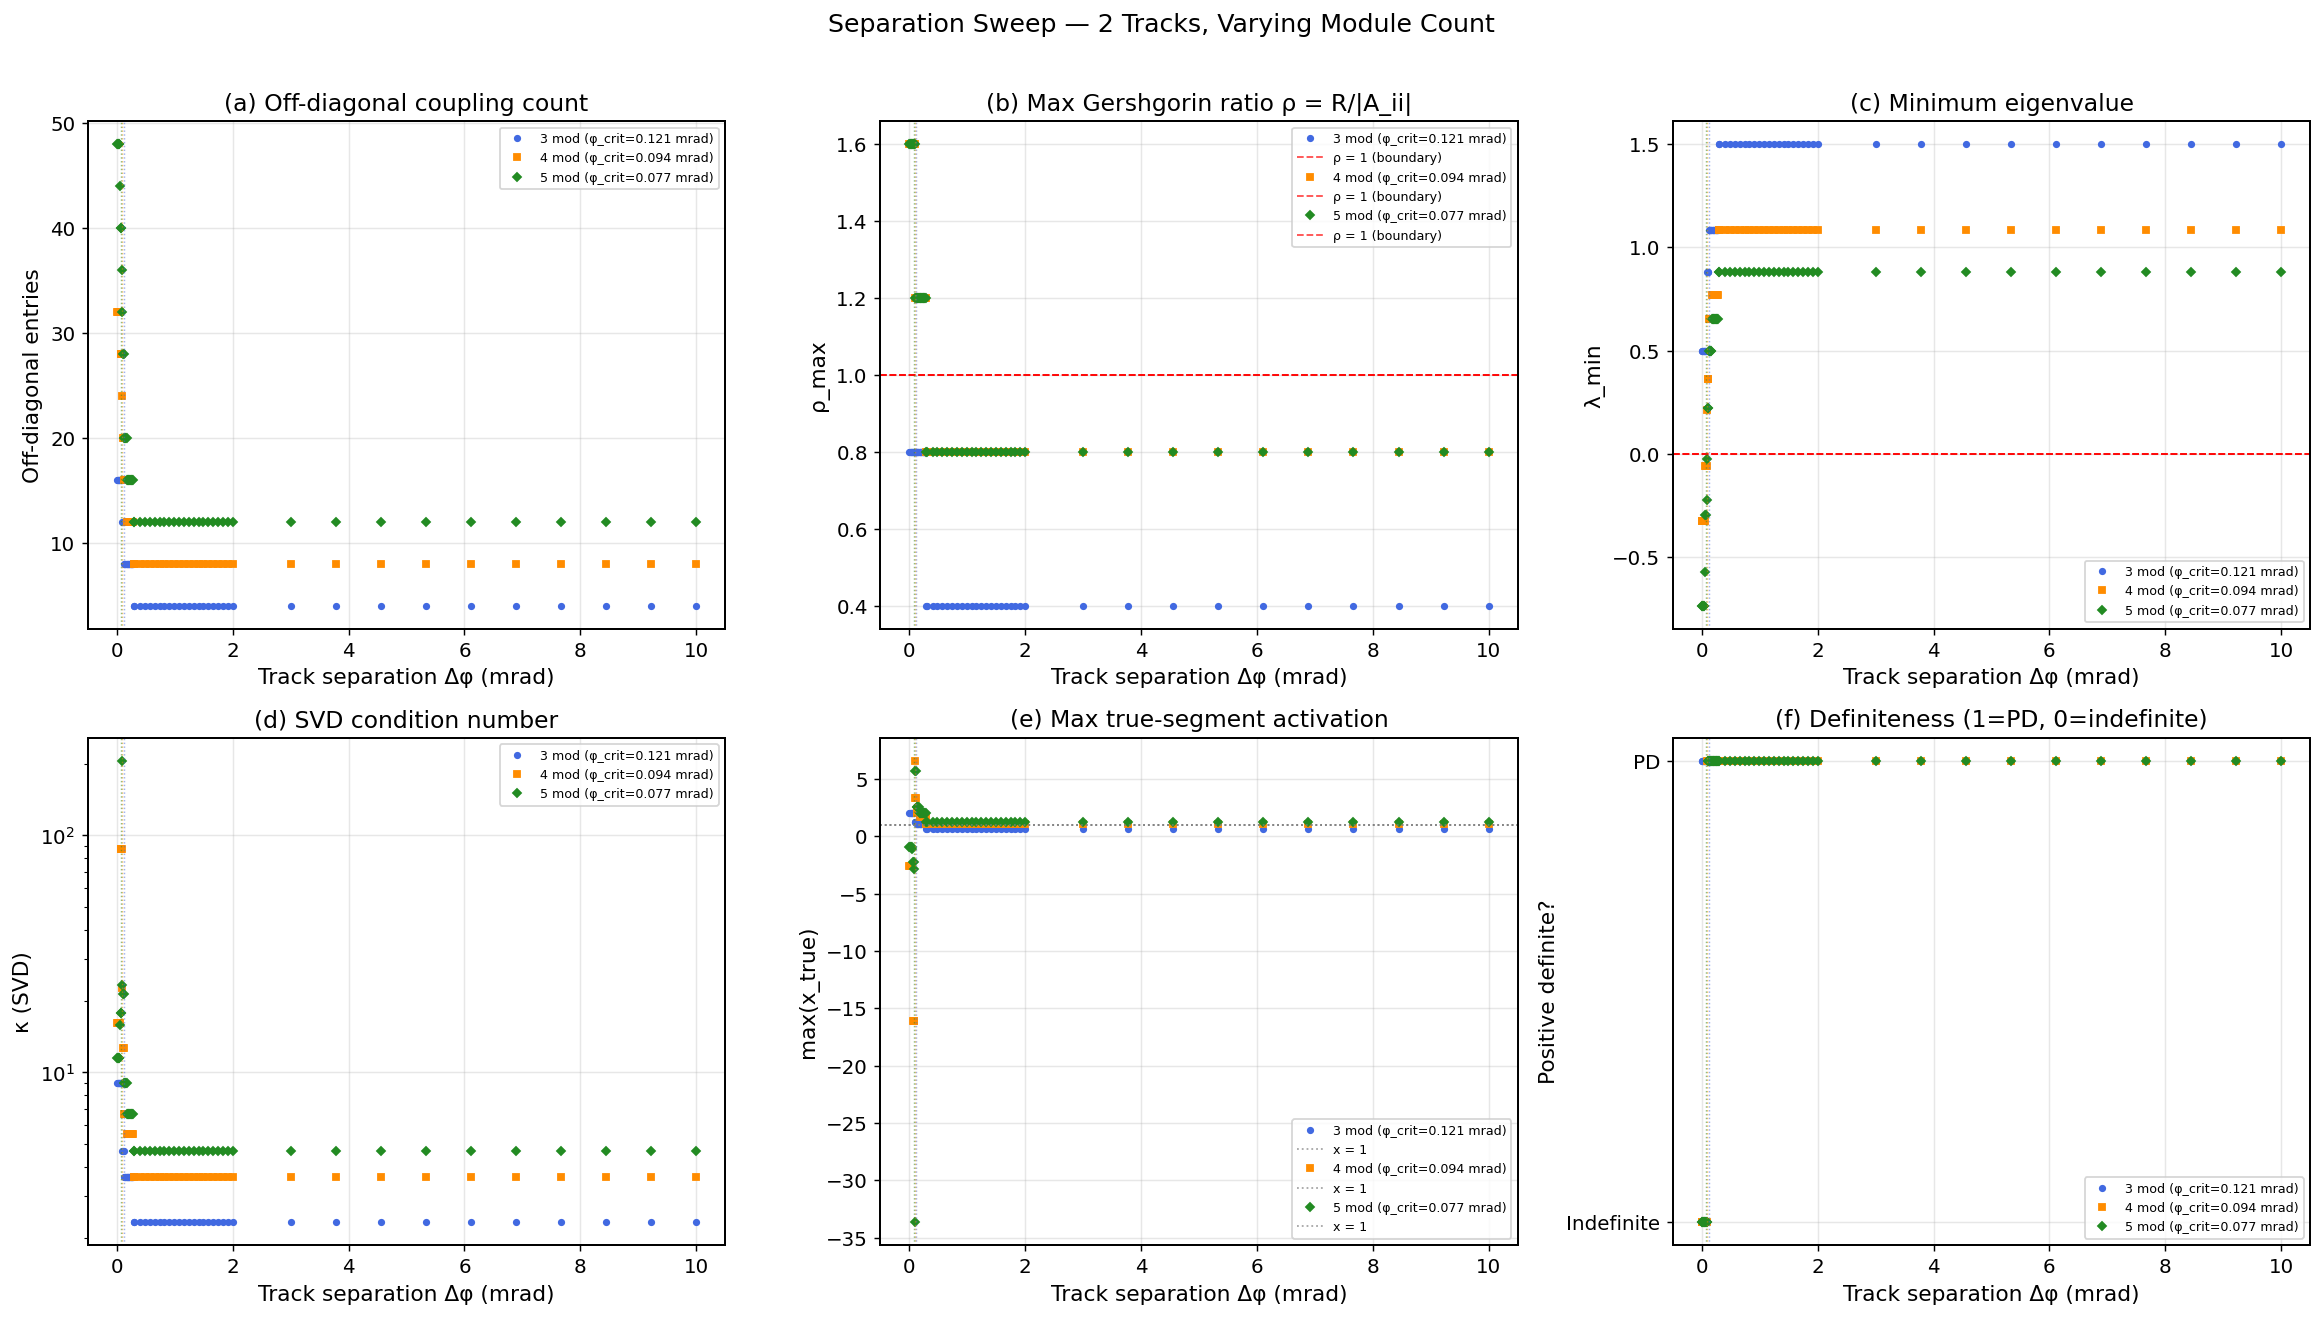

In [12]:
# ── 5b. Sweep visualisation (6-panel) ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Compute critical separation for each module count
for n_mod, color, marker in [(3, 'royalblue', 'o'), (4, 'darkorange', 's'), (5, 'forestgreen', 'D')]:
    subset = [r for r in sweep_results if r['n_mod'] == n_mod]
    seps = np.array([r['sep']*1e3 for r in subset])  # mrad
    
    # f_amp_max for this geometry
    z_positions = [100 + i*DZ_MM for i in range(n_mod)]
    f_amp_max = max((z - Z_PV)/DZ_MM for z in z_positions[1:])  # exclude first module
    phi_crit = EPSILON / f_amp_max * 1e3  # mrad
    
    label = f'{n_mod} mod (φ_crit={phi_crit:.3f} mrad)'
    
    # (a) Off-diagonal count
    axes[0,0].plot(seps, [r['n_offdiag'] for r in subset], marker, ms=3, color=color, label=label)
    axes[0,0].set_ylabel('Off-diagonal entries')
    axes[0,0].set_title('(a) Off-diagonal coupling count')
    
    # (b) Max Gershgorin ratio
    axes[0,1].plot(seps, [r['rho_max'] for r in subset], marker, ms=3, color=color, label=label)
    axes[0,1].set_ylabel('ρ_max')
    axes[0,1].set_title('(b) Max Gershgorin ratio ρ = R/|A_ii|')
    axes[0,1].axhline(1.0, color='red', ls='--', lw=1, alpha=0.7, label='ρ = 1 (boundary)')
    
    # (c) Minimum eigenvalue
    axes[0,2].plot(seps, [r['lam_min'] for r in subset], marker, ms=3, color=color, label=label)
    axes[0,2].set_ylabel('λ_min')
    axes[0,2].set_title('(c) Minimum eigenvalue')
    axes[0,2].axhline(0, color='red', ls='--', lw=1, alpha=0.7)
    
    # (d) Condition number
    axes[1,0].plot(seps, [r['kappa'] for r in subset], marker, ms=3, color=color, label=label)
    axes[1,0].set_ylabel('κ (SVD)')
    axes[1,0].set_title('(d) SVD condition number')
    axes[1,0].set_yscale('log')
    
    # (e) Max true activation
    axes[1,1].plot(seps, [r['x_true_max'] for r in subset], marker, ms=3, color=color, label=label)
    axes[1,1].set_ylabel('max(x_true)')
    axes[1,1].set_title('(e) Max true-segment activation')
    axes[1,1].axhline(1.0, color='grey', ls=':', lw=1, alpha=0.7, label='x = 1')
    
    # (f) Positive definite?
    axes[1,2].plot(seps, [1 if r['is_pd'] else 0 for r in subset], marker, ms=3, color=color, label=label)
    axes[1,2].set_ylabel('Positive definite?')
    axes[1,2].set_title('(f) Definiteness (1=PD, 0=indefinite)')
    axes[1,2].set_yticks([0, 1])
    axes[1,2].set_yticklabels(['Indefinite', 'PD'])

for ax in axes.flat:
    ax.set_xlabel('Track separation Δφ (mrad)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Add critical separation vertical lines
for n_mod, color in [(3, 'royalblue'), (4, 'darkorange'), (5, 'forestgreen')]:
    z_positions = [100 + i*DZ_MM for i in range(n_mod)]
    f_amp_max = max((z - Z_PV)/DZ_MM for z in z_positions[1:])
    phi_crit = EPSILON / f_amp_max * 1e3
    for ax in axes.flat:
        ax.axvline(phi_crit, color=color, ls=':', lw=0.8, alpha=0.5)

fig.suptitle('Separation Sweep — 2 Tracks, Varying Module Count', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_separation_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Why Activations Exceed 1.0: Analytic Explanation

The observation that true-segment activations reach $\approx 1.27$ is **not a bug** — it is an expected consequence of the linear algebra.

### Analytic derivation for a single isolated track

For a 5-module detector, a single track produces 4 segments forming a tridiagonal chain:

$$
\begin{pmatrix}
\delta+\gamma & -1 & 0 & 0 \\
-1 & \delta+\gamma & -1 & 0 \\
0 & -1 & \delta+\gamma & -1 \\
0 & 0 & -1 & \delta+\gamma
\end{pmatrix}
\begin{pmatrix} x_0 \\ x_1 \\ x_2 \\ x_3 \end{pmatrix}
=
\begin{pmatrix} \delta \\ \delta \\ \delta \\ \delta \end{pmatrix}
$$

With $\delta=1$, $\gamma=1.5$ (so diagonal $= 2.5$), the symmetric solution ($x_0=x_3$, $x_1=x_2$) gives:

From row 0: $2.5\,x_0 - x_1 = 1$  
From row 1: $-x_0 + 2.5\,x_1 - x_2 = 1$, and $x_1 = x_2$, so $-x_0 + 1.5\,x_1 = 1$

Solving: $x_0 = 10/11 \approx 0.909$, $x_1 = 14/11 \approx 1.273$.

**The interior segments have $x > 1$ because they receive more coupling support** (two neighbours vs one for end segments). This is a mathematical property of the system, not a solver failure. The activation values are not probabilities — they are solutions to a linear system designed so that true-segment activations exceed the threshold $\tau = 0.7$.

In [13]:
# ── 6a. Verify analytic predictions vs solver for 1–4 tracks ────────────────
print("Analytic vs numerical activations for a SINGLE isolated track:")
print("="*65)

for n_mod in [3, 4, 5, 6]:
    # Single track — no cross-couplings possible
    ev, geo, angs = gen_colinear_event(1, n_mod, base_angle=0.01, separation_rad=0.0)
    ham = build_ham(ev)
    A = get_matrix_dense(ham)
    sol = spsolve(ham.A, ham.b)
    is_true = label_segments(ham, ev)
    
    n_seg_true = n_mod - 1
    true_activations = sol[is_true]
    
    print(f"\n{n_mod} modules ({n_seg_true} segments):")
    print(f"  Activations: {np.round(true_activations, 4)}")
    print(f"  Min = {true_activations.min():.4f}, Max = {true_activations.max():.4f}")
    print(f"  Exceeds 1.0? {'YES' if true_activations.max() > 1.0 else 'No'}"
          f"  (by {(true_activations.max()-1.0)*100:.1f}%)" if true_activations.max() > 1 else "")

Analytic vs numerical activations for a SINGLE isolated track:

3 modules (2 segments):
  Activations: [0.6667 0.6667]
  Min = 0.6667, Max = 0.6667


4 modules (3 segments):
  Activations: [0.8235 1.0588 0.8235]
  Min = 0.8235, Max = 1.0588
  Exceeds 1.0? YES  (by 5.9%)

5 modules (4 segments):
  Activations: [0.9091 1.2727 1.2727 0.9091]
  Min = 0.9091, Max = 1.2727
  Exceeds 1.0? YES  (by 27.3%)

6 modules (5 segments):
  Activations: [0.9538 1.3846 1.5077 1.3846 0.9538]
  Min = 0.9538, Max = 1.5077
  Exceeds 1.0? YES  (by 50.8%)


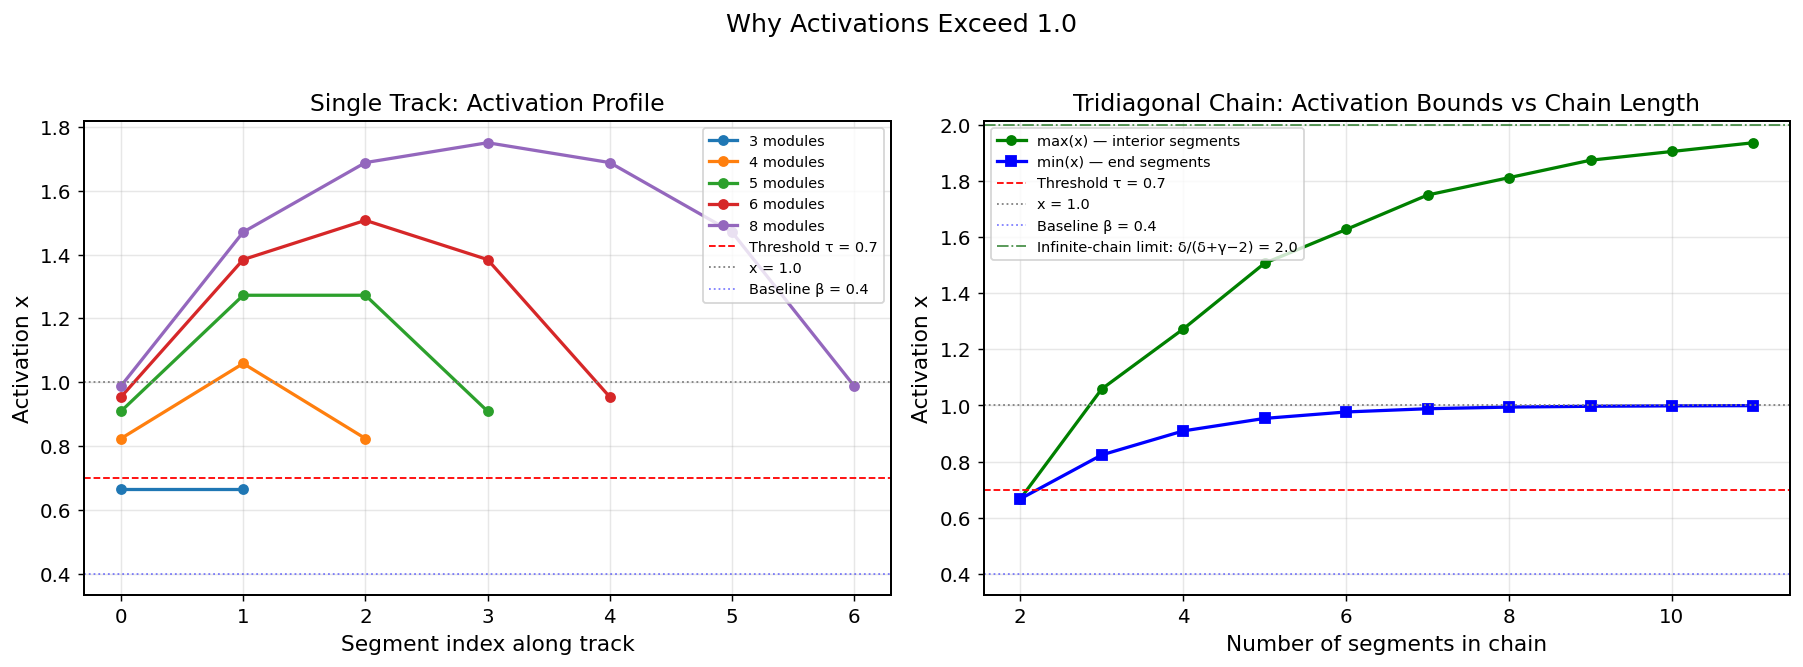


For an infinite tridiagonal chain with d=2.5, δ=1.0:
  Interior activation → δ/(d-2) = 1.0/(2.5-2) = 2.0000
  This is the theoretical maximum for isolated-track activations.


In [14]:
# ── 6b. Activation profile plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Single track, varying number of modules
ax = axes[0]
for n_mod in [3, 4, 5, 6, 8]:
    ev, geo, angs = gen_colinear_event(1, n_mod, base_angle=0.01, separation_rad=0.0)
    ham = build_ham(ev)
    sol = spsolve(ham.A, ham.b)
    is_true = label_segments(ham, ev)
    true_x = sol[is_true]
    ax.plot(range(len(true_x)), true_x, 'o-', label=f'{n_mod} modules')

ax.axhline(THRESHOLD, color='red', ls='--', lw=1, label=f'Threshold τ = {THRESHOLD}')
ax.axhline(1.0, color='grey', ls=':', lw=1, label='x = 1.0')
ax.axhline(BASELINE, color='blue', ls=':', lw=1, alpha=0.5, label=f'Baseline β = {BASELINE}')
ax.set_xlabel('Segment index along track')
ax.set_ylabel('Activation x')
ax.set_title('Single Track: Activation Profile')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Analytic formula for tridiagonal solution
ax = axes[1]
d = DELTA + GAMMA  # = 2.5
delta = DELTA       # = 1.0

n_seg_range = range(2, 12)
max_acts = []
min_acts = []
for n_seg in n_seg_range:
    # Build the isolated tridiagonal block
    T = np.diag([d]*n_seg) + np.diag([-1]*(n_seg-1), 1) + np.diag([-1]*(n_seg-1), -1)
    b_vec = np.ones(n_seg) * delta
    x_sol = np.linalg.solve(T, b_vec)
    max_acts.append(x_sol.max())
    min_acts.append(x_sol.min())

ax.plot(list(n_seg_range), max_acts, 'o-', color='green', label='max(x) — interior segments')
ax.plot(list(n_seg_range), min_acts, 's-', color='blue', label='min(x) — end segments')
ax.axhline(THRESHOLD, color='red', ls='--', lw=1, label=f'Threshold τ = {THRESHOLD}')
ax.axhline(1.0, color='grey', ls=':', lw=1, label='x = 1.0')
ax.axhline(BASELINE, color='blue', ls=':', lw=1, alpha=0.5, label=f'Baseline β = {BASELINE}')

# Analytic limiting value for infinite chain: x → δ/(δ+γ-2) = 1/(2.5-2) = 2.0
x_inf = delta / (d - 2) if d > 2 else np.inf
ax.axhline(x_inf, color='darkgreen', ls='-.', lw=1, alpha=0.7,
           label=f'Infinite-chain limit: δ/(δ+γ−2) = {x_inf:.1f}')

ax.set_xlabel('Number of segments in chain')
ax.set_ylabel('Activation x')
ax.set_title('Tridiagonal Chain: Activation Bounds vs Chain Length')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Why Activations Exceed 1.0', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_activation_exceeds_1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFor an infinite tridiagonal chain with d={d}, δ={delta}:")
print(f"  Interior activation → δ/(d-2) = {delta}/({d}-2) = {x_inf:.4f}")
print(f"  This is the theoretical maximum for isolated-track activations.")

---
## 7 — CG vs Direct Solver on Small Indefinite Systems

We compare the Conjugate Gradient solver (which requires positive definiteness) against a direct solver (LU/Cholesky via `spsolve`) on the controlled indefinite systems.

In [15]:
# ── 7. CG vs Direct solver comparison ──────────────────────────────────────
print(f"{'Config':<28}  {'PD?':>4}  {'κ':>8}  {'CG max|x|':>10}  {'Direct max|x|':>13}  "
      f"{'CG-Direct RMSE':>14}  {'CG converged?':>13}")
print('-'*105)

solver_results = []
for n_mod in [3, 4, 5]:
    for n_trk in [1, 2, 3]:
        for sep in [0.0, 5e-5, 1e-3]:
            if n_trk == 1 and sep > 0:
                continue  # separation meaningless for 1 track
            
            ev, geo, angs = gen_colinear_event(n_trk, n_mod, base_angle=0.01, separation_rad=sep)
            ham = build_ham(ev)
            A = get_matrix_dense(ham)
            eigs, _, kappa, is_pd = spectral_analysis(A)
            
            # Direct solve
            x_direct = spsolve(ham.A, ham.b)
            
            # CG solve
            x_cg, info = cg(ham.A, ham.b, atol=1e-10)
            
            rmse = np.sqrt(np.mean((x_cg - x_direct)**2))
            
            label = f"{n_mod}mod, {n_trk}trk, Δφ={sep*1e3:.2f}mrad"
            print(f"{label:<28}  {'Y' if is_pd else 'N':>4}  {kappa:>8.1f}  "
                  f"{np.max(np.abs(x_cg)):>10.3f}  {np.max(np.abs(x_direct)):>13.3f}  "
                  f"{rmse:>14.2e}  {'Yes' if info == 0 else f'No (info={info})':>13}")
            
            solver_results.append({
                'label': label, 'is_pd': is_pd, 'kappa': kappa,
                'x_cg': x_cg, 'x_direct': x_direct, 'rmse': rmse,
                'cg_converged': info == 0, 'n_mod': n_mod, 'n_trk': n_trk,
                'sep': sep,
            })

Config                         PD?         κ   CG max|x|  Direct max|x|  CG-Direct RMSE  CG converged?
---------------------------------------------------------------------------------------------------------
3mod, 1trk, Δφ=0.00mrad          Y       2.3       0.667          0.667        0.00e+00            Yes
3mod, 2trk, Δφ=0.00mrad          Y       9.0       2.000          2.000        2.48e-16            Yes
3mod, 2trk, Δφ=0.05mrad          Y       9.0       2.000          2.000        2.48e-16            Yes
3mod, 2trk, Δφ=1.00mrad          Y       2.3       0.667          0.667        0.00e+00            Yes
3mod, 3trk, Δφ=0.00mrad          N      11.0       2.000          2.000        6.90e-16            Yes
3mod, 3trk, Δφ=0.05mrad          N      11.0       2.000          2.000        6.90e-16            Yes
3mod, 3trk, Δφ=1.00mrad          Y       2.3       0.667          0.667        7.85e-17            Yes
4mod, 1trk, Δφ=0.00mrad          Y       3.6       1.059          1.05

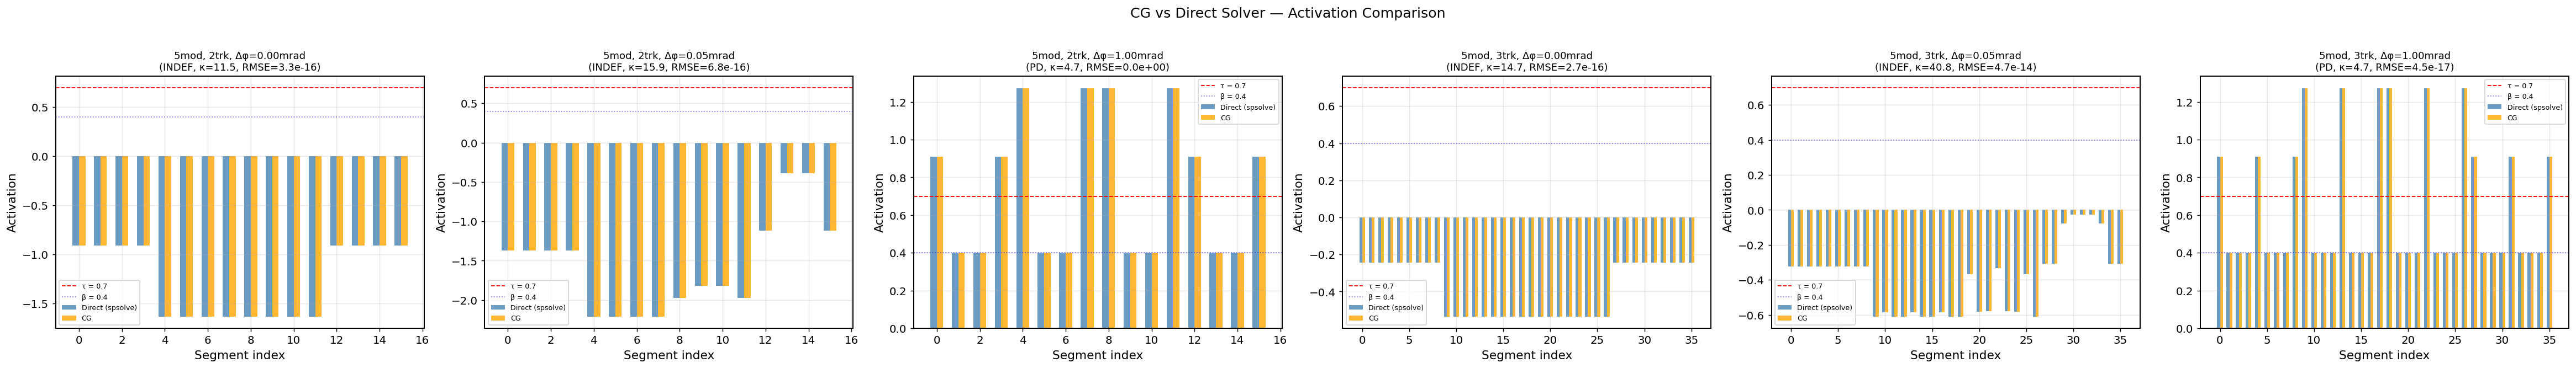

In [16]:
# ── 7b. Activation comparison plots ────────────────────────────────────────
# Pick a few interesting cases to visualise
interesting = [r for r in solver_results if r['n_mod'] == 5 and r['n_trk'] >= 2]

if interesting:
    fig, axes = plt.subplots(1, len(interesting), figsize=(6*len(interesting), 5))
    if len(interesting) == 1:
        axes = [axes]
    
    for ax, r in zip(axes, interesting):
        n = len(r['x_direct'])
        ax.bar(np.arange(n)-0.15, r['x_direct'], 0.3, label='Direct (spsolve)', color='steelblue', alpha=0.8)
        ax.bar(np.arange(n)+0.15, r['x_cg'], 0.3, label='CG', color='orange', alpha=0.8)
        ax.axhline(THRESHOLD, color='red', ls='--', lw=1, label=f'τ = {THRESHOLD}')
        ax.axhline(BASELINE, color='blue', ls=':', lw=1, alpha=0.5, label=f'β = {BASELINE}')
        ax.set_xlabel('Segment index')
        ax.set_ylabel('Activation')
        pd_str = 'PD' if r['is_pd'] else 'INDEF'
        ax.set_title(f"{r['label']}\n({pd_str}, κ={r['kappa']:.1f}, RMSE={r['rmse']:.1e})", fontsize=10)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('CG vs Direct Solver — Activation Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_cg_vs_direct.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No interesting solver comparison cases found.")

---
## 8 — Block Structure: Does Damage Stay Localised?

In a realistic event with many tracks, only the near-coincident pair produces the pathological sub-block. We check whether the block-diagonal structure limits the damage to that sub-block.

In [17]:
# ── 8. Mixed event: 1 colinear pair + well-separated tracks ────────────────
# Create a 5-module event with 4 tracks: 2 colinear + 2 well-separated
N_MOD_FULL = 5
geo_full = make_geometry(N_MOD_FULL)

gen = StateEventGenerator(
    detector_geometry=geo_full, events=1, n_particles=[4],
    phi_min=-0.3, phi_max=0.3, theta_min=-0.3, theta_max=0.3,
    measurement_error=0.0, collision_noise=0.0,
)
gen.set_primary_vertices([(0.0, 0.0, Z_PV)])
gen.generate_particles([[{"type": "pion", "mass": 139.6, "q": 1}]*4])

# Track 0 & 1: colinear (separation ~ 0)
# Track 2 & 3: well separated
np.random.seed(42)
gen.particles[0][0]['tx'] = np.tan(0.01)
gen.particles[0][0]['ty'] = 0.0
gen.particles[0][1]['tx'] = np.tan(0.01 + 2e-5)  # 0.02 mrad separation — well within ε/f_amp
gen.particles[0][1]['ty'] = 0.0
gen.particles[0][2]['tx'] = np.tan(0.05)   # far away
gen.particles[0][2]['ty'] = np.tan(0.03)
gen.particles[0][3]['tx'] = np.tan(-0.04)  # far away, different direction
gen.particles[0][3]['ty'] = np.tan(-0.02)

ev_mixed = gen.generate_complete_events()
ham_mixed = build_ham(ev_mixed)
A_mixed = get_matrix_dense(ham_mixed)
is_true_mixed = label_segments(ham_mixed, ev_mixed)

# Solve
x_direct = spsolve(ham_mixed.A, ham_mixed.b)
x_cg, cg_info = cg(ham_mixed.A, ham_mixed.b, atol=1e-10)

eigs, svs, kappa, is_pd = spectral_analysis(A_mixed)

print(f"Mixed event: {len(ev_mixed.tracks)} tracks, {ham_mixed.n_segments} segments")
print(f"Matrix: {A_mixed.shape[0]}×{A_mixed.shape[1]}")
print(f"PD: {is_pd}, κ = {kappa:.1f}, λ_min = {eigs.min():.4f}")
print(f"\nDirect solve:")
print(f"  True activations:  {np.round(x_direct[is_true_mixed], 3)}")
print(f"  False mean: {x_direct[~is_true_mixed].mean():.4f}")
print(f"\nCG solve (converged={cg_info==0}):")
print(f"  True activations:  {np.round(x_cg[is_true_mixed], 3)}")
print(f"  False mean: {x_cg[~is_true_mixed].mean():.4f}")
print(f"\nRMSE(CG vs Direct) = {np.sqrt(np.mean((x_cg - x_direct)**2)):.2e}")

Mixed event: 4 tracks, 64 segments
Matrix: 64×64
PD: False, κ = 11.5, λ_min = -0.7361

Direct solve:
  True activations:  [-0.909 -0.909  0.909  0.909 -1.636 -1.636  1.273  1.273 -1.636 -1.636
  1.273  1.273 -0.909 -0.909  0.909  0.909]
  False mean: 0.1212

CG solve (converged=True):
  True activations:  [-0.909 -0.909  0.909  0.909 -1.636 -1.636  1.273  1.273 -1.636 -1.636
  1.273  1.273 -0.909 -0.909  0.909  0.909]
  False mean: 0.1212

RMSE(CG vs Direct) = 4.11e-16


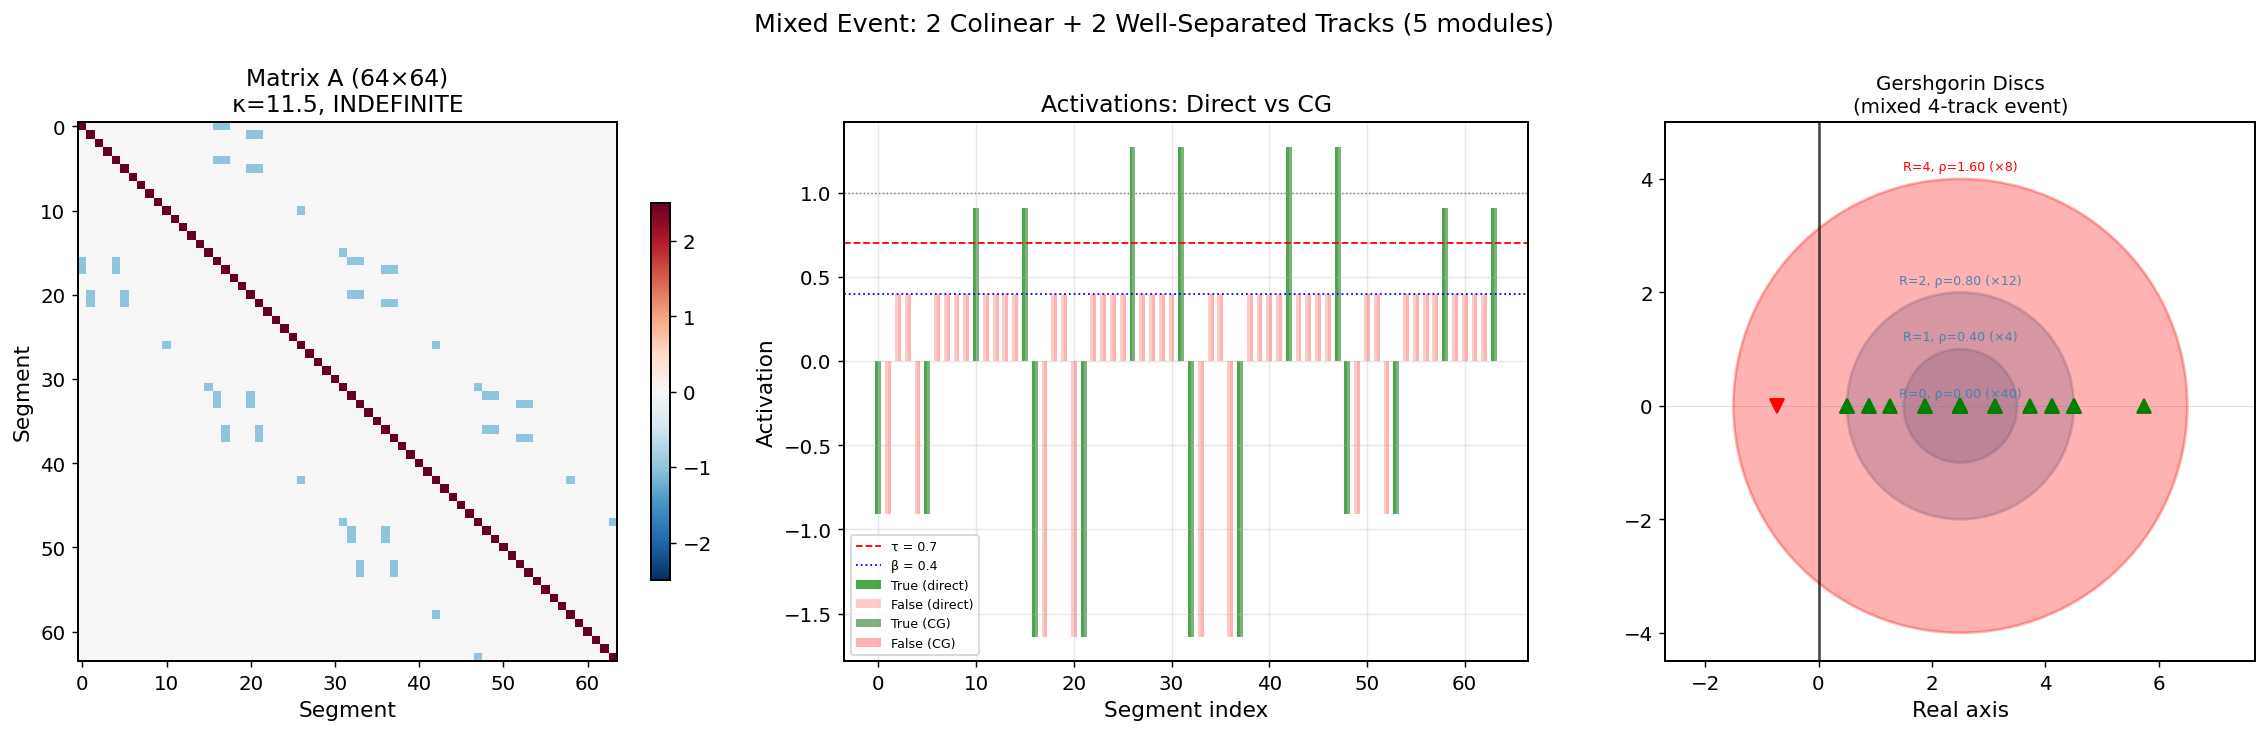

In [18]:
# ── 8b. Visualise the mixed-event matrix and activations ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Matrix heatmap
ax = axes[0]
n = A_mixed.shape[0]
vmax = max(abs(A_mixed.min()), abs(A_mixed.max()))
im = ax.imshow(A_mixed, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
ax.set_title(f'Matrix A ({n}×{n})\nκ={kappa:.1f}, {"PD" if is_pd else "INDEFINITE"}')
ax.set_xlabel('Segment'); ax.set_ylabel('Segment')
fig.colorbar(im, ax=ax, shrink=0.7)

# (b) Activation comparison
ax = axes[1]
idx = np.arange(n)
ax.bar(idx[is_true_mixed]-0.15, x_direct[is_true_mixed], 0.3, color='green', alpha=0.7, label='True (direct)')
ax.bar(idx[~is_true_mixed]-0.15, x_direct[~is_true_mixed], 0.3, color='salmon', alpha=0.4, label='False (direct)')
ax.bar(idx[is_true_mixed]+0.15, x_cg[is_true_mixed], 0.3, color='darkgreen', alpha=0.5, label='True (CG)')
ax.bar(idx[~is_true_mixed]+0.15, x_cg[~is_true_mixed], 0.3, color='red', alpha=0.3, label='False (CG)')
ax.axhline(THRESHOLD, color='red', ls='--', lw=1, label=f'τ = {THRESHOLD}')
ax.axhline(BASELINE, color='blue', ls=':', lw=1, label=f'β = {BASELINE}')
ax.axhline(1.0, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Segment index')
ax.set_ylabel('Activation')
ax.set_title('Activations: Direct vs CG')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (c) Gershgorin discs
plot_gershgorin(A_mixed, axes[2], f'Gershgorin Discs\n(mixed 4-track event)')

fig.suptitle('Mixed Event: 2 Colinear + 2 Well-Separated Tracks (5 modules)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_mixed_event.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9 — γ Sensitivity: What Diagonal Strength Prevents Indefiniteness?

The diagonal entry is $A_{ii} = \delta + \gamma$. For the matrix to stay positive definite, we need $A_{ii} > R_i^{\max}$ (strict diagonal dominance). We sweep $\gamma$ to find the minimum value that guarantees PD for each configuration.

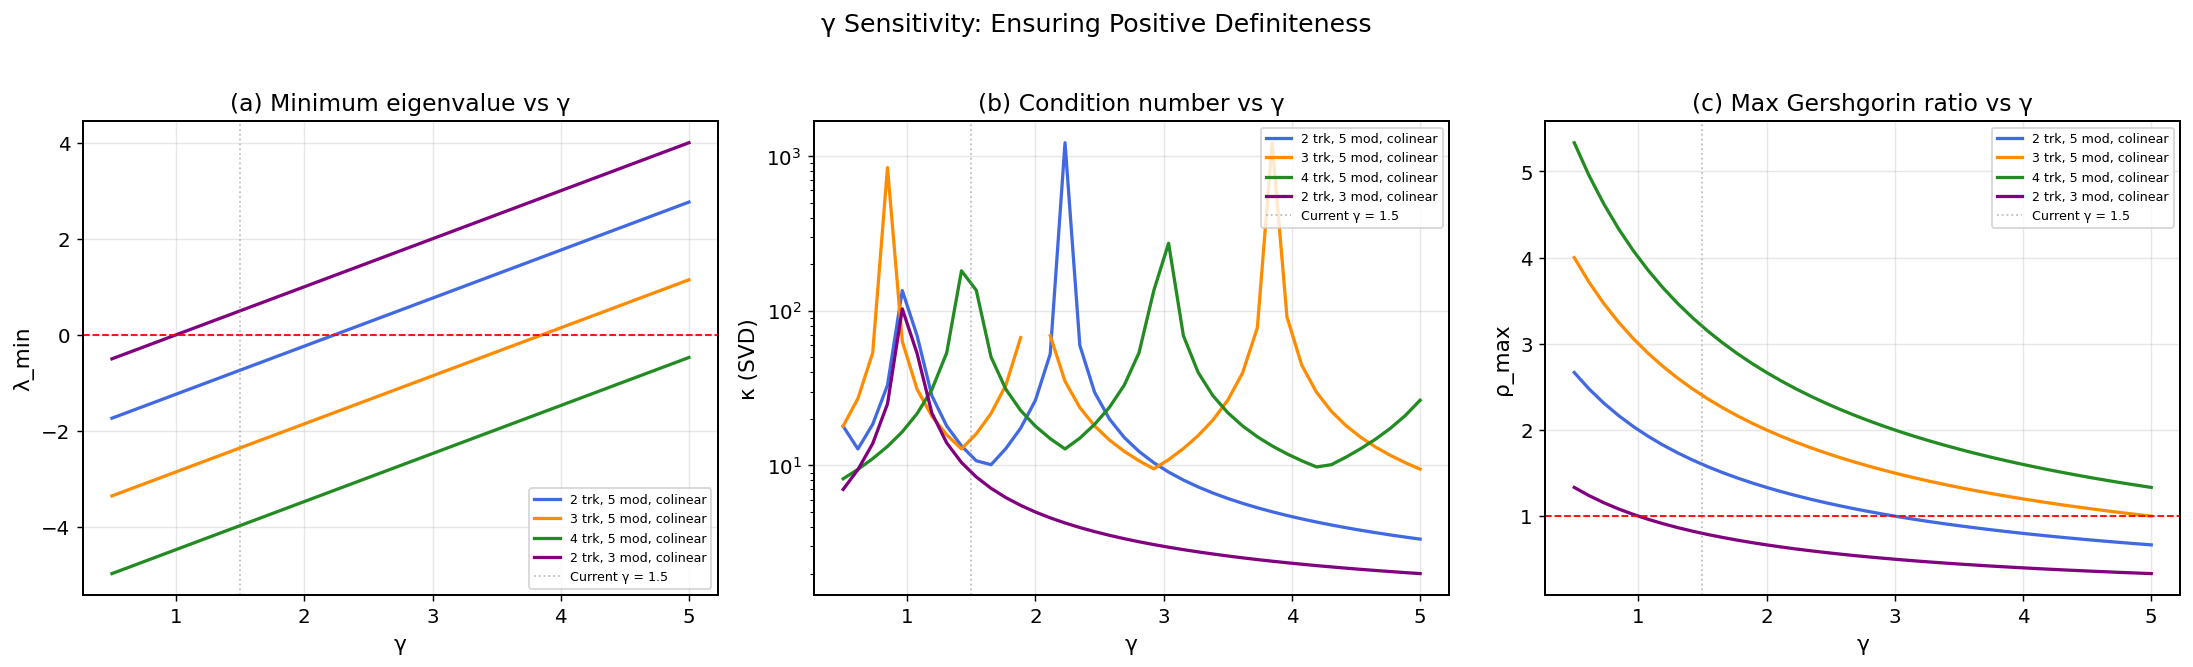


Minimum γ for positive definiteness (from sweep):
  2 trk, 5 mod, colinear: γ_crit ≈ 2.35 (diagonal = 3.35)
  3 trk, 5 mod, colinear: γ_crit ≈ 3.96 (diagonal = 4.96)
  4 trk, 5 mod, colinear: γ > 5.0 needed
  2 trk, 3 mod, colinear: γ_crit ≈ 1.08 (diagonal = 2.08)


In [19]:
# ── 9. γ sweep ──────────────────────────────────────────────────────────────
gamma_values = np.linspace(0.5, 5.0, 40)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

configs_to_test = [
    (2, 5, 0.0, 'royalblue', '2 trk, 5 mod, colinear'),
    (3, 5, 0.0, 'darkorange', '3 trk, 5 mod, colinear'),
    (4, 5, 0.0, 'forestgreen', '4 trk, 5 mod, colinear'),
    (2, 3, 0.0, 'purple', '2 trk, 3 mod, colinear'),
]

for n_trk, n_mod, sep, color, label in configs_to_test:
    lam_mins = []
    kappas = []
    rho_maxs = []
    
    for g in gamma_values:
        ev, geo, angs = gen_colinear_event(n_trk, n_mod, base_angle=0.01, separation_rad=sep)
        ham = build_ham(ev, gamma=g)
        A = get_matrix_dense(ham)
        eigs, _, kappa, _ = spectral_analysis(A)
        _, _, ratios = gershgorin_discs(A)
        lam_mins.append(eigs.min())
        kappas.append(kappa)
        rho_maxs.append(ratios.max())
    
    axes[0].plot(gamma_values, lam_mins, '-', color=color, label=label)
    axes[1].plot(gamma_values, kappas, '-', color=color, label=label)
    axes[2].plot(gamma_values, rho_maxs, '-', color=color, label=label)

axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_ylabel('λ_min')
axes[0].set_title('(a) Minimum eigenvalue vs γ')

axes[1].set_ylabel('κ (SVD)')
axes[1].set_title('(b) Condition number vs γ')
axes[1].set_yscale('log')

axes[2].axhline(1.0, color='red', ls='--', lw=1)
axes[2].set_ylabel('ρ_max')
axes[2].set_title('(c) Max Gershgorin ratio vs γ')

for ax in axes:
    ax.axvline(GAMMA, color='grey', ls=':', lw=1, alpha=0.5, label=f'Current γ = {GAMMA}')
    ax.set_xlabel('γ')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('γ Sensitivity: Ensuring Positive Definiteness', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_gamma_sensitivity_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

# Report the critical γ for each config
print("\nMinimum γ for positive definiteness (from sweep):")
for n_trk, n_mod, sep, _, label in configs_to_test:
    for g in gamma_values:
        ev, geo, angs = gen_colinear_event(n_trk, n_mod, base_angle=0.01, separation_rad=sep)
        ham = build_ham(ev, gamma=g)
        A = get_matrix_dense(ham)
        eigs = eigvalsh(A)
        if eigs.min() > 0:
            print(f"  {label}: γ_crit ≈ {g:.2f} (diagonal = {DELTA + g:.2f})")
            break
    else:
        print(f"  {label}: γ > {gamma_values[-1]:.1f} needed")

---
## 10 — Row-Level Anatomy: Where Does Diagonal Dominance Break?

Zoom into the matrix rows for a colinear 2-track event to see exactly which segments violate diagonal dominance and why.

In [20]:
# ── 10. Row-level analysis for a 5-module colinear 2-track event ───────────
ev5, geo5, ang5 = gen_colinear_event(2, 5, base_angle=0.01, separation_rad=0.0)
ham5 = build_ham(ev5)
A5 = get_matrix_dense(ham5)
is_true5 = label_segments(ham5, ev5)

n = A5.shape[0]
centres5, radii5, ratios5 = gershgorin_discs(A5)

print(f"5-module, 2-track colinear event: {n} segments")
print(f"{'Seg':>4}  {'From→To':>10}  {'True':>5}  {'A_ii':>6}  {'R_i':>6}  {'ρ_i':>6}  {'Couplings':>10}")
print('-'*60)
for i in range(n):
    fid, tid = ham5._segment_to_hit_ids[i]
    couplings = [(j, A5[i,j]) for j in range(n) if j != i and A5[i,j] != 0]
    coup_str = ', '.join([f'{j}' for j, v in couplings])
    flag = '✓' if is_true5[i] else '✗'
    warn = '  ◄ VIOLATED' if ratios5[i] > 1 else ''
    print(f"{i:>4}  {fid:>4}→{tid:<4}  {flag:>5}  {centres5[i]:>6.1f}  {radii5[i]:>6.1f}  "
          f"{ratios5[i]:>6.2f}  [{coup_str}]{warn}")

5-module, 2-track colinear event: 16 segments
 Seg     From→To   True    A_ii     R_i     ρ_i   Couplings
------------------------------------------------------------
   0     0→1         ✓     2.5     2.0    0.80  [4, 5]
   1     0→6         ✗     2.5     2.0    0.80  [6, 7]
   2     5→1         ✗     2.5     2.0    0.80  [4, 5]
   3     5→6         ✓     2.5     2.0    0.80  [6, 7]
   4     1→2         ✓     2.5     4.0    1.60  [0, 2, 8, 9]  ◄ VIOLATED
   5     1→7         ✗     2.5     4.0    1.60  [0, 2, 10, 11]  ◄ VIOLATED
   6     6→2         ✗     2.5     4.0    1.60  [1, 3, 8, 9]  ◄ VIOLATED
   7     6→7         ✓     2.5     4.0    1.60  [1, 3, 10, 11]  ◄ VIOLATED
   8     2→3         ✓     2.5     4.0    1.60  [4, 6, 12, 13]  ◄ VIOLATED
   9     2→8         ✗     2.5     4.0    1.60  [4, 6, 14, 15]  ◄ VIOLATED
  10     7→3         ✗     2.5     4.0    1.60  [5, 7, 12, 13]  ◄ VIOLATED
  11     7→8         ✓     2.5     4.0    1.60  [5, 7, 14, 15]  ◄ VIOLATED
  12     3→4     

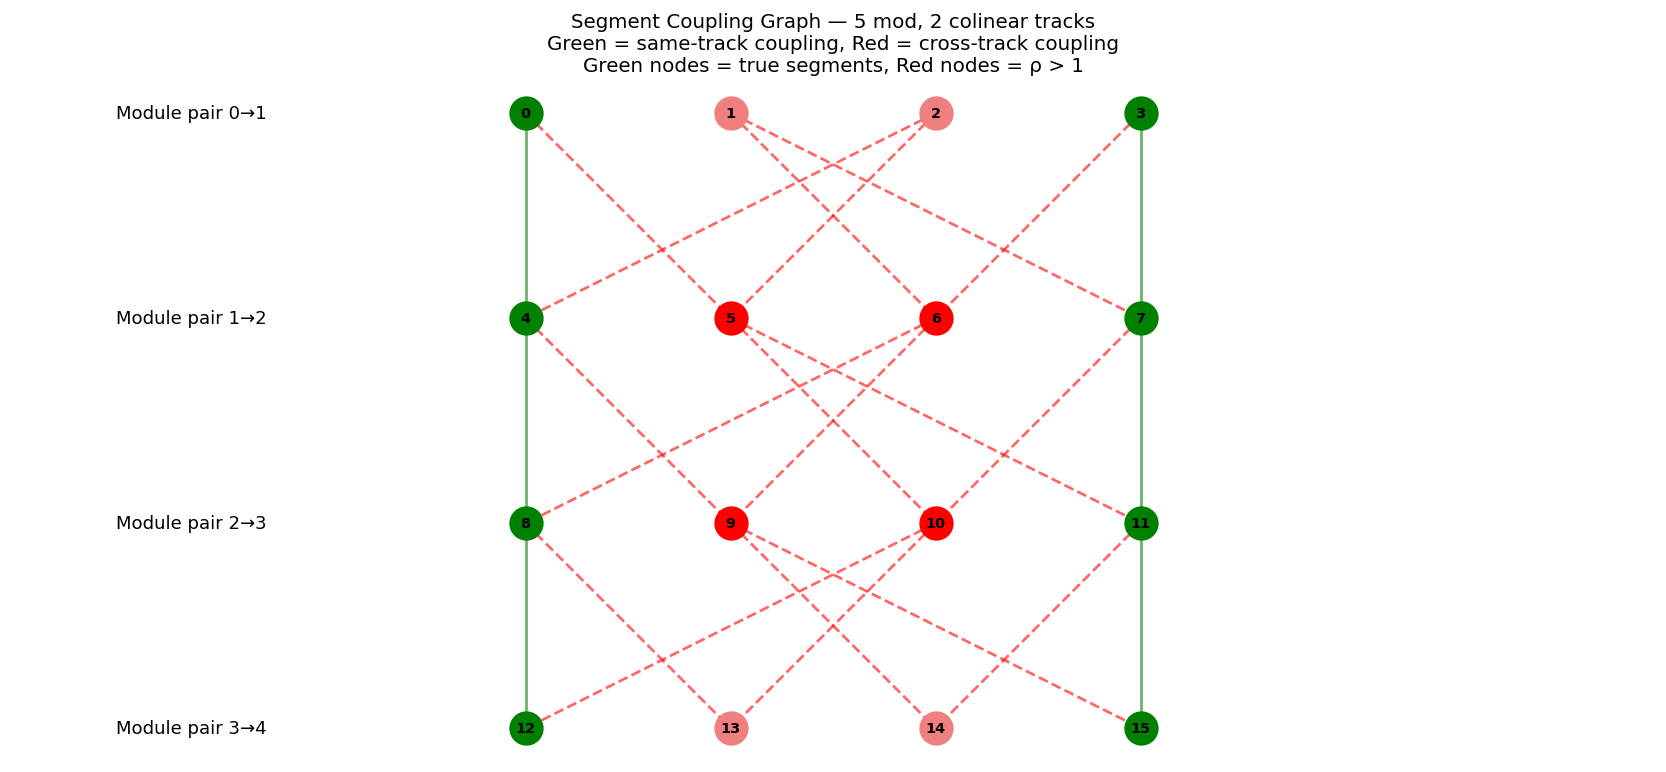

In [21]:
# ── 10b. Coupling graph visualisation ──────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Position segments by module pair (y) and within-pair index (x)
group_boundaries = ham5._group_boundaries
positions = {}
for g in range(len(group_boundaries)-1):
    start = group_boundaries[g]
    end = group_boundaries[g+1]
    n_in_group = end - start
    for local_i, seg_i in enumerate(range(start, end)):
        x = local_i - (n_in_group-1)/2  # centre within group
        y = -g  # groups go downward
        positions[seg_i] = (x, y)

# Draw nodes
for i in range(n):
    x, y = positions[i]
    color = 'green' if is_true5[i] else ('red' if ratios5[i] > 1 else 'lightcoral')
    ax.plot(x, y, 'o', color=color, markersize=18, zorder=3)
    ax.text(x, y, f'{i}', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)

# Draw coupling edges
for i in range(n):
    for j in range(i+1, n):
        if A5[i, j] != 0:
            xi, yi = positions[i]
            xj, yj = positions[j]
            # Determine if this is same-track or cross-track coupling
            same_track = (is_true5[i] and is_true5[j])
            color = 'green' if same_track else 'red'
            ls = '-' if same_track else '--'
            ax.plot([xi, xj], [yi, yj], ls, color=color, lw=1.5, alpha=0.6, zorder=1)

# Labels
for g in range(len(group_boundaries)-1):
    y = -g
    ax.text(-3.5, y, f'Module pair {g}→{g+1}', fontsize=10, va='center')

ax.set_xlim(-4, 4)
ax.set_title('Segment Coupling Graph — 5 mod, 2 colinear tracks\n'
             'Green = same-track coupling, Red = cross-track coupling\n'
             'Green nodes = true segments, Red nodes = ρ > 1', fontsize=11)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_coupling_graph.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11 — Summary of Findings

### Matrix Structure at the Edge Case

1. **Segment construction is geometry-driven**: $(M-1) \times n^2$ segments are always created, regardless of track separation. What changes with separation is whether **cross-segment couplings** pass the angle test.

2. **The transition is sharp**: When $\Delta\phi < \varepsilon / f_\text{amp}$, cross-couplings inject additional $-1$ entries into the matrix. The off-diagonal count jumps from $\sim 2(M-2)$ per track to $\sim 4(M-2)$ per shared-window pair.

3. **Gershgorin radii quantify the damage**: Each cross-coupling adds 1 to $R_i$. With $n$ colinear tracks, the worst-case $R_i$ can reach $\sim 2(n-1)(M-2)$, while $A_{ii} = \delta + \gamma = 2.5$ stays fixed. For 2 colinear tracks on 5 modules, $R_\max = 4 > 2.5 = A_{ii}$.

4. **Indefiniteness is the root failure**: The matrix acquires negative eigenvalues, violating the SPD requirement for CG. The SVD condition number stays moderate ($\kappa \sim 7$–$30$).

5. **Block structure limits damage**: In a mixed event (some colinear, some separated), only the sub-block involving the colinear pair is pathological. The direct solver gives correct results for all segments; CG may propagate errors.

### Activations Exceeding 1.0

6. **$x > 1$ is expected and correct**: For a single isolated track on $M \geq 4$ modules, interior segments receive coupling support from two neighbours, yielding $x > 1$. The analytic maximum for $\gamma = 1.5$, $\delta = 1.0$ is $x \to \delta/(\delta + \gamma - 2) = 2.0$ as the chain length $\to \infty$. For 5 modules: $x_\text{interior} = 14/11 \approx 1.273$.

7. **The Hamiltonian was not designed to bound activations in $[0, 1]$**: The system $Ax = b$ is a linear equation, not a probabilistic model. Activations serve as a score that is compared to the threshold $\tau$.

### Implications for the Quantum Algorithm

8. **Any quantum solver (HHL) also requires the matrix to be Hermitian positive semi-definite.** The indefiniteness issue affects quantum and classical solvers equally.

9. **A sufficient condition for PD** is $\gamma + \delta > R_\max$, i.e. the diagonal must exceed the maximum possible row sum. For $n$ colinear tracks on $M$ modules, this requires $\gamma > R_\max - \delta$.